# HLE Dimensionality Analysis — CFA & Robust Alternatives
Sharma, Nadela, Matteson · CS321M · Stanford 2026

**Analysis pipeline:**
1. ω_h from 2PL discrimination parameters (N-robust primary evidence)
2. PCA on item response profiles + domain R² test
3. Domain accuracy profiles + inter-domain Spearman ρ heatmap
4. Parallel coordinates plot — are model rankings domain-specific?
5. General-factor loading distributions per domain (violin + strip)
6. ω_h vs Cronbach α reliability comparison
7. Residual correlation structure after removing g

> **Note on tetrachoric CFA:** With N=22 models and J=408 items, tetrachoric R is
> non-positive-definite and CFA-based fit indices (CFI, RMSEA) are invalid.
> All analyses below are N-robust.


## 0. Setup

In [30]:
!pip install -q torch_measure datasets matplotlib seaborn scipy scikit-learn

In [31]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from torch_measure.models import TwoPL
from torch_measure.metrics import tetrachoric_correlation, cronbach_alpha


## 1. Load response matrix and item metadata

In [32]:
# ── Response matrix ──────────────────────────────────────────────────────────
df_raw = pd.read_csv("response_matrix.csv", index_col=0)

EXCLUDE_THRESHOLD = 0.70   # drop models with < 70% coverage
coverage = df_raw.notna().mean(axis=1)
excluded = coverage[coverage < EXCLUDE_THRESHOLD].index.tolist()
df_clean = df_raw.drop(index=excluded).fillna(0.0)

# Remove zero-variance items
zero_var = df_clean.columns[df_clean.var(axis=0) == 0]
df_clean = df_clean.drop(columns=zero_var)

X = torch.tensor(df_clean.values, dtype=torch.float32)
N, J = X.shape
print(f"Analytic matrix: N={N} models × J={J} items")
print(f"Excluded models ({len(excluded)}): {excluded}")
print(f"Zero-variance items removed: {len(zero_var)}")

# ── Reasoning model labels ────────────────────────────────────────────────────
REASONING_MODELS = {
    "o3-mini",
    "o4-mini",
    "qwq-32b-16k8k",
    "sky-t1-32b-16k8k",
}
model_names = list(df_clean.index)
is_reasoning_vec = [m in REASONING_MODELS for m in model_names]
print(f"\nReasoning-specialized models retained: "
      f"{[m for m in model_names if m in REASONING_MODELS]}")
print(f"Standard instruction-tuned models: "
      f"{sum(not r for r in is_reasoning_vec)}")


Analytic matrix: N=29 models × J=428 items
Excluded models: ['deepseek-r1', 'gpt-5-nano', 'gemini-2-5-pro', 'deepseek-v4-flash', 'deepseek-v4-pro', 'gemma9b-8k4k', 'phi4-16k8k']
Zero-variance items removed: 85


In [33]:
# ── HLE item metadata: domain labels ─────────────────────────────────────────
try:
    from datasets import load_dataset
    hle = load_dataset("cais/hle", split="test")
    hle_df = hle.to_pandas()[["id", "answer_type", "category"]]
    hle_mc  = hle_df[hle_df["answer_type"] == "multipleChoice"].set_index("id")
    item_domains = hle_mc.reindex(df_clean.columns)["category"].fillna("Other")
    HAS_DOMAINS = True
    print("Domain distribution:")
    print(item_domains.value_counts().to_string())
except Exception as e:
    print(f"Could not load HLE metadata ({e}). Using placeholder domains.")
    item_domains = pd.Series("Unknown", index=df_clean.columns)
    HAS_DOMAINS = False

domain_list   = sorted(item_domains.unique())
n_domains     = len(domain_list)
domain_to_idx = {d: i for i, d in enumerate(domain_list)}
item_domain_idx = torch.tensor([domain_to_idx[d] for d in item_domains], dtype=torch.long)

Domain distribution:
category
Biology/Medicine             122
Math                          78
Humanities/Social Science     71
Computer Science/AI           54
Other                         37
Physics                       26
Chemistry                     22
Engineering                   18


## 1. Publication style

In [34]:

# ── Publication style constants ──────────────────────────────────────────────
# Colour palette: editorial navy + warm accent, colourblind-safe domain colours
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Base style
plt.rcParams.update({
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "axes.edgecolor":      "#2d2d2d",
    "axes.linewidth":      0.8,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           True,
    "axes.grid.axis":      "both",
    "grid.color":          "#e8e8e8",
    "grid.linewidth":      0.5,
    "axes.labelsize":      11,
    "axes.labelcolor":     "#2d2d2d",
    "axes.titlesize":      12,
    "axes.titleweight":    "semibold",
    "axes.titlecolor":     "#1a1a1a",
    "xtick.labelsize":     9,
    "ytick.labelsize":     9,
    "xtick.color":         "#4d4d4d",
    "ytick.color":         "#4d4d4d",
    "legend.fontsize":     9,
    "legend.framealpha":   0.92,
    "legend.edgecolor":    "#cccccc",
    "figure.dpi":          150,
    "savefig.dpi":         300,
    "savefig.bbox":        "tight",
    "font.family":         "serif",
    "font.serif":          ["Palatino Linotype", "Palatino", "Book Antiqua",
                            "Georgia", "DejaVu Serif"],
    "mathtext.fontset":    "dejavuserif",
})

# Domain colour palette (colourblind-safe, 8 colours)
DOMAIN_PALETTE = {
    "Biology/Medicine":          "#2166ac",
    "Math":                      "#d6604d",
    "Humanities/Social Science": "#4dac26",
    "Computer Science/AI":       "#8073ac",
    "Physics":                   "#f4a582",
    "Chemistry":                 "#1a9641",
    "Engineering":               "#fdae61",
    "Other":                     "#878787",
    "Unknown":                   "#cccccc",
}

NAVY   = "#1c3557"
ACCENT = "#c0392b"
TEAL   = "#16a085"
MID    = "#7f8c8d"

def domain_color(d):
    return DOMAIN_PALETTE.get(d, "#878787")

print("Publication style loaded.")


Publication style loaded.


## 2. ω_h from 2PL parameters (primary evidence)

In [35]:
# ── §1. ω_h from 2PL (primary N-robust evidence) ────────────────────────────
from torch_measure.models import TwoPL

irt = TwoPL(n_subjects=N, n_items=J)
irt.fit(X, method="mle", max_epochs=2000, lr=0.05, verbose=True)

a_raw     = irt.discrimination.detach()
b_hat_all = irt.difficulty.detach()
A_CAP     = 5.0
a_hat     = a_raw.clamp(max=A_CAP)
theta_hat = irt.ability.detach()
theta_overall = theta_hat.numpy()

# λ_j = a_j / sqrt(1 + a_j²)  — normal-ogive general-factor loading
lam    = (a_hat / torch.sqrt(1 + a_hat**2)).numpy()
unique = 1 - lam**2
omega_h = float(lam.sum()**2 / (lam.sum()**2 + unique.sum()))
print(f"ω_h (McDonald, from 2PL): {omega_h:.4f}")

# Per-domain ω_h
domain_stats = {}
if HAS_DOMAINS:
    for d in domain_list:
        mask  = (item_domains == d).values
        lam_d = lam[mask]
        if len(lam_d) < 3: continue
        oh  = float(lam_d.sum()**2 / (lam_d.sum()**2 + (1-lam_d**2).sum()))
        n_d = mask.sum()
        domain_stats[d] = {"n": n_d, "omega_h": oh,
                           "mean_lam": lam_d.mean(), "med_lam": np.median(lam_d)}
    for d, s in sorted(domain_stats.items(), key=lambda x: -x[1]["omega_h"]):
        print(f"  {d:30s}  n={s['n']:3d}  ω_h={s['omega_h']:.3f}  mean λ={s['mean_lam']:.3f}")


MLE fitting:  25%|██▍       | 498/2000 [00:00<00:01, 1047.47it/s, loss=0.318466]


ω_h (McDonald, from 2PL): 0.9984
  Biology/Medicine                n=122  ω_h=0.994  mean λ=0.733
  Humanities/Social Science       n= 71  ω_h=0.993  mean λ=0.788
  Computer Science/AI             n= 54  ω_h=0.992  mean λ=0.818
  Math                            n= 78  ω_h=0.991  mean λ=0.748
  Chemistry                       n= 22  ω_h=0.972  mean λ=0.751
  Other                           n= 37  ω_h=0.971  mean λ=0.668
  Physics                         n= 26  ω_h=0.966  mean λ=0.698
  Engineering                     n= 18  ω_h=0.936  mean λ=0.661


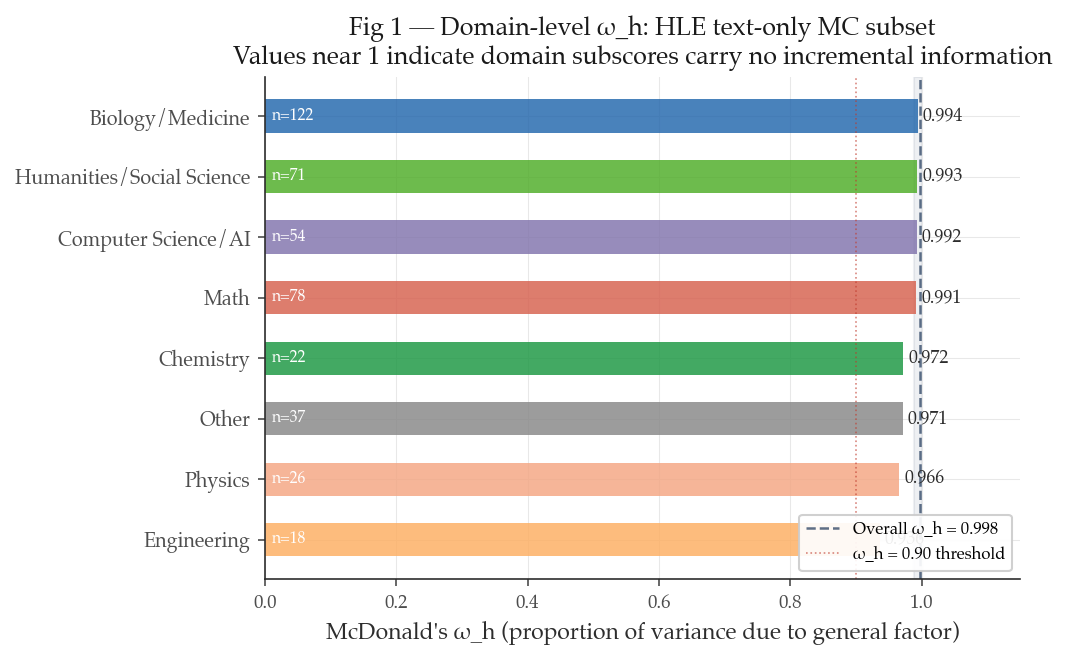

In [36]:

# ── Fig 1: ω_h per domain — dot + CI strip ───────────────────────────────────
if HAS_DOMAINS and domain_stats:
    fig, ax = plt.subplots(figsize=(7, 4.5))

    domains_sorted = sorted(domain_stats.keys(), key=lambda d: domain_stats[d]["omega_h"])
    ys   = np.arange(len(domains_sorted))
    ohs  = [domain_stats[d]["omega_h"] for d in domains_sorted]
    ns   = [domain_stats[d]["n"]       for d in domains_sorted]
    cols = [domain_color(d)             for d in domains_sorted]

    # Overall ω_h reference band
    ax.axvspan(omega_h - 0.01, 1.0, alpha=0.07, color=NAVY, zorder=0)
    ax.axvline(omega_h, color=NAVY, lw=1.2, linestyle="--", alpha=0.7,
               label=f"Overall ω_h = {omega_h:.3f}")

    # Bars
    bars = ax.barh(ys, ohs, color=cols, alpha=0.82, height=0.55, zorder=2)

    # Annotate n= and ω_h value
    for i, (oh, n, d) in enumerate(zip(ohs, ns, domains_sorted)):
        ax.text(oh + 0.008, i, f"{oh:.3f}", va="center", ha="left",
                fontsize=8.5, color="#2d2d2d")
        ax.text(0.01, i, f"n={n}", va="center", ha="left",
                fontsize=7.5, color="white", fontweight="bold", zorder=3)

    ax.set_yticks(ys)
    ax.set_yticklabels(domains_sorted, fontsize=9.5)
    ax.set_xlim(0, 1.12)
    ax.set_xlabel("McDonald's ω_h (proportion of variance due to general factor)")
    ax.set_title("Fig 1 — Domain-level ω_h: HLE text-only MC subset\n"
                 "Values near 1 indicate domain subscores carry no incremental information")
    ax.axvline(0.90, color=ACCENT, lw=0.8, linestyle=":", alpha=0.6, label="ω_h = 0.90 threshold")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(0, 1.15)

    plt.tight_layout()
    plt.savefig("fig1_omega_h_by_domain.pdf")
    plt.savefig("fig1_omega_h_by_domain.png")
    plt.show()


## 3. PCA on item response profiles

In [37]:

# ── §2. PCA on item response profiles ────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_items = X.numpy().T   # (J, N)
pca = PCA(n_components=min(N, 10), random_state=42)
Z   = pca.fit_transform(X_items)
var_exp = pca.explained_variance_ratio_

print("Variance explained by PC:","".join([f"\n  PC{i+1}: {v*100:.1f}%" for i, v in enumerate(var_exp)]))
print(f"\nCumulative PC1-3: {var_exp[:3].sum()*100:.1f}%")
print(f"Cumulative PC1-8: {var_exp[:8].sum()*100:.1f}%")

# PERMANOVA-style test: do domain labels explain PCA variance?
# Use centroid dispersion ratio
if HAS_DOMAINS:
    from scipy.spatial.distance import cdist
    total_var  = np.var(Z[:, :3], axis=0).sum()
    within_var = 0.0
    for d in domain_list:
        mask = (item_domains == d).values
        if mask.sum() < 2: continue
        within_var += np.var(Z[mask, :3], axis=0).sum() * mask.sum()
    within_var /= J
    between_var = total_var - within_var
    r2_pca = between_var / total_var
    print(f"\nDomain R² in PC1-3 space: {r2_pca:.4f}  ({r2_pca*100:.1f}% of variance explained by domain)")
    print("(R²≈0 → domain labels explain nothing → general factor)")


Variance explained by PC: 
  PC1: 16.0%
  PC2: 8.1%
  PC3: 5.9%
  PC4: 5.3%
  PC5: 4.8%
  PC6: 4.2%
  PC7: 4.1%
  PC8: 3.8%
  PC9: 3.6%
  PC10: 3.3%

Cumulative PC1-3: 29.9%
Cumulative PC1-8: 52.0%

Domain R² in PC1-3 space: 0.0353  (3.5% of variance explained by domain)
(R²≈0 → domain labels explain nothing → general factor)


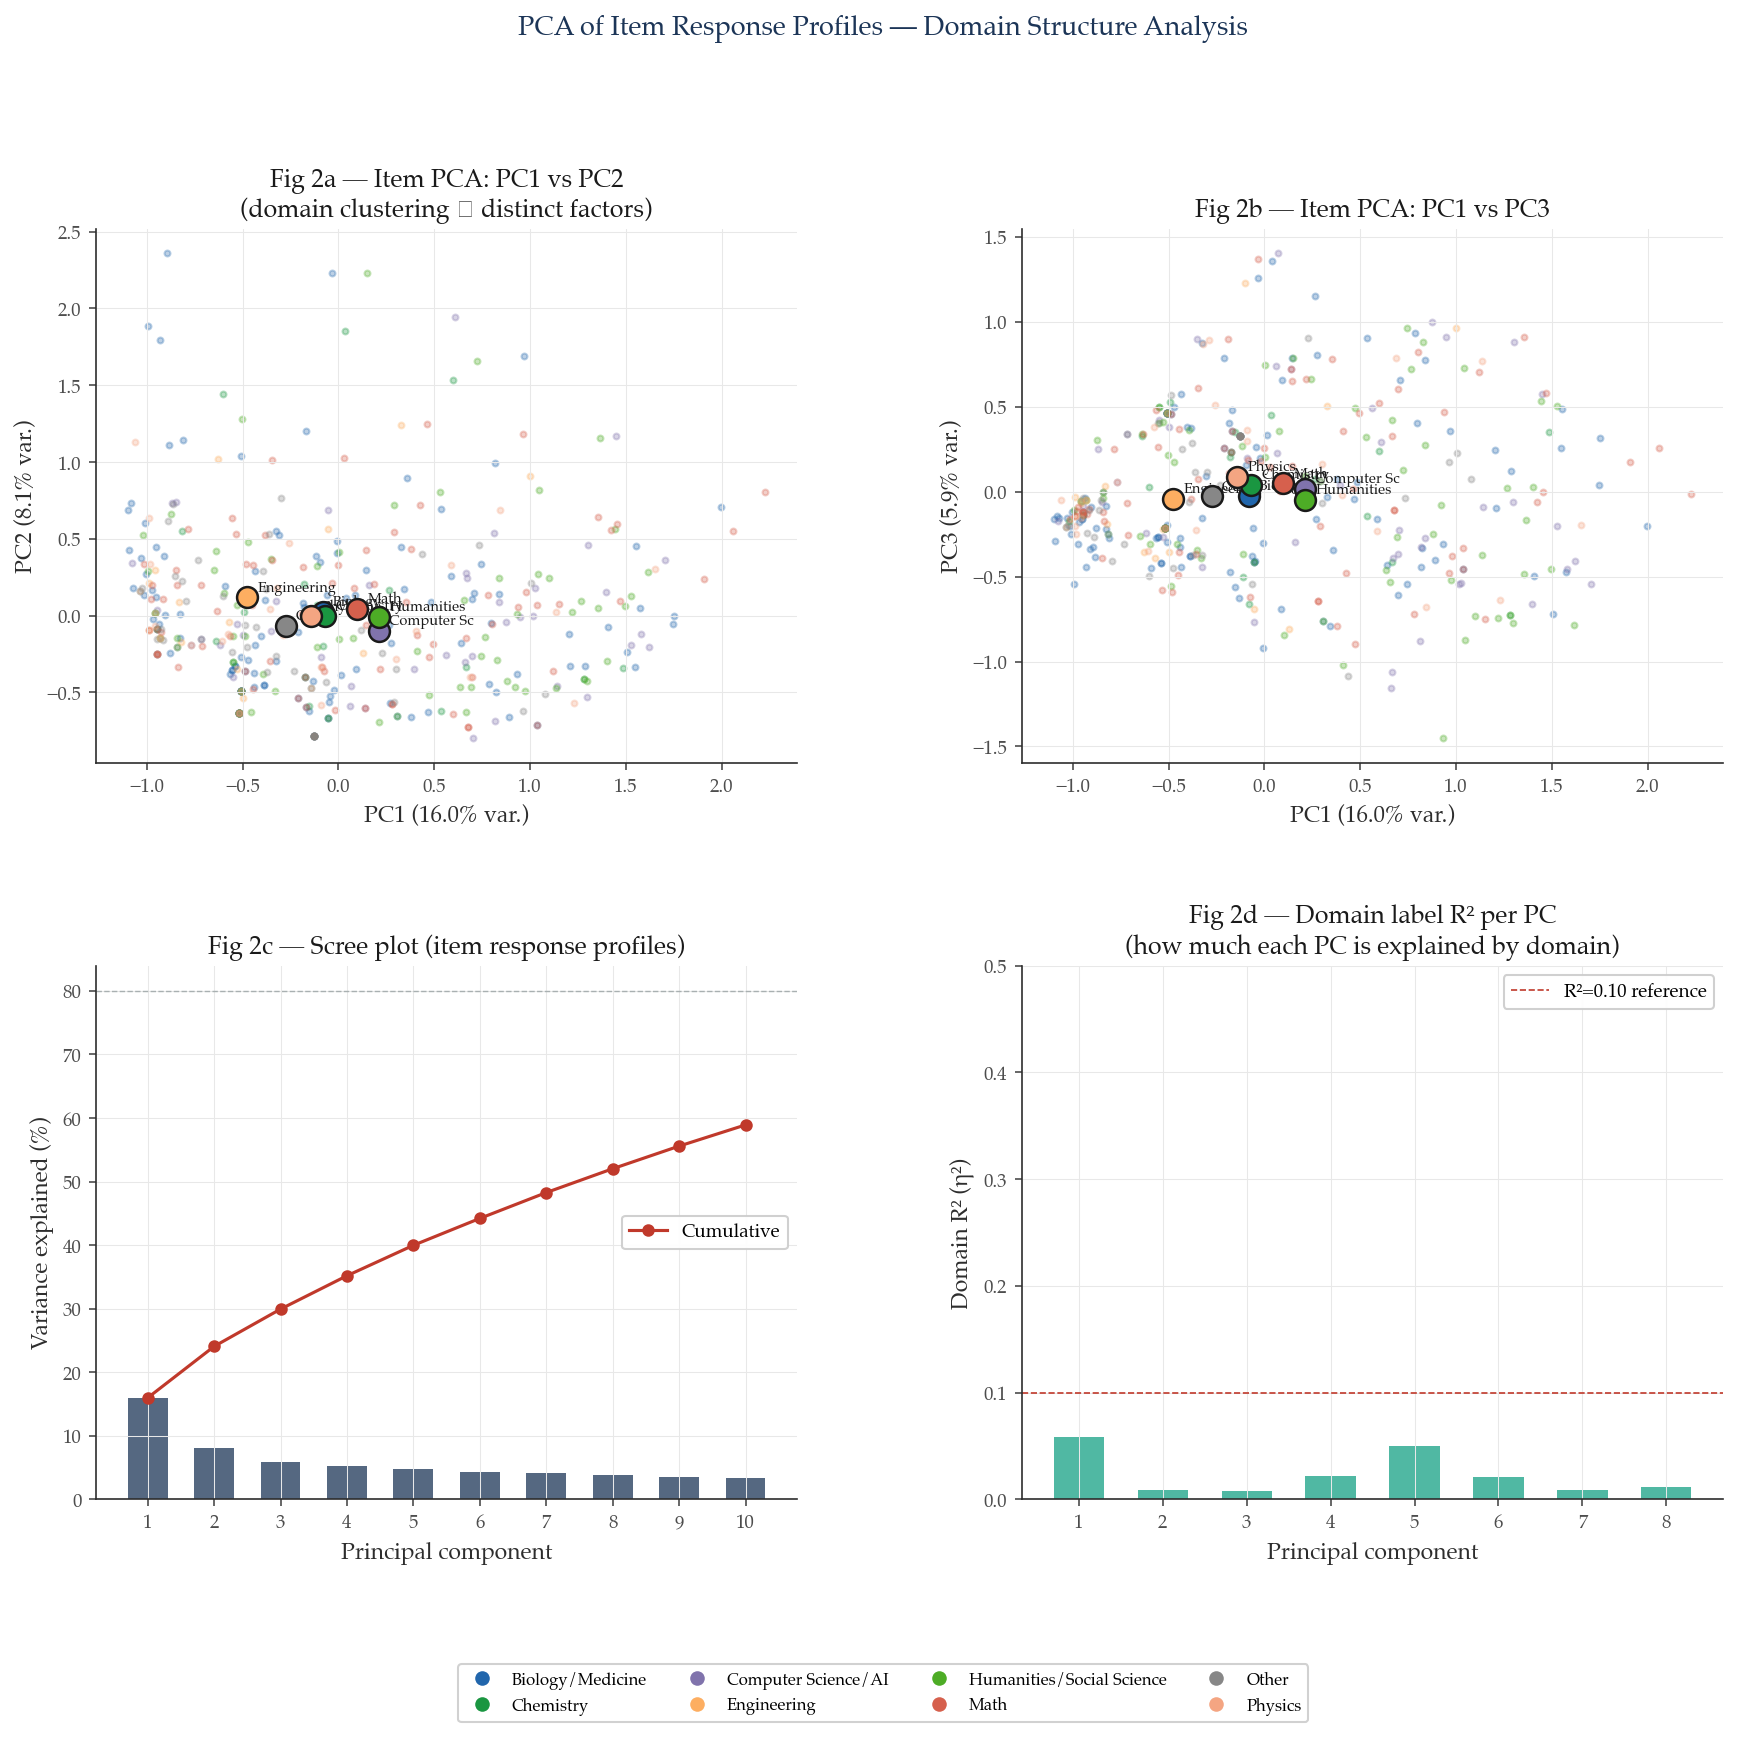

In [38]:

# ── Fig 2: PCA scatter + loading plot ────────────────────────────────────────
if HAS_DOMAINS:
    fig = plt.figure(figsize=(14, 11))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

    ax_pc12  = fig.add_subplot(gs[0, 0])
    ax_pc13  = fig.add_subplot(gs[0, 1])
    ax_scree = fig.add_subplot(gs[1, 0])
    ax_r2    = fig.add_subplot(gs[1, 1])

    # ── PC1 vs PC2 ──────────────────────────────────────────────────────────
    for d in domain_list:
        mask = (item_domains == d).values
        ax_pc12.scatter(Z[mask, 0], Z[mask, 1],
                        c=domain_color(d), alpha=0.3, s=8, label=d)
    # Centroids
    for d in domain_list:
        mask = (item_domains == d).values
        if mask.sum() < 2: continue
        cx, cy = Z[mask, 0].mean(), Z[mask, 1].mean()
        ax_pc12.scatter(cx, cy, c=domain_color(d), s=100,
                        edgecolors="#1a1a1a", lw=1.2, zorder=5)
        ax_pc12.annotate(d.split("/")[0][:11], (cx, cy),
                         fontsize=7, xytext=(5, 3),
                         textcoords="offset points", color="#1a1a1a")
    ax_pc12.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% var.)")
    ax_pc12.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% var.)")
    ax_pc12.set_title("Fig 2a — Item PCA: PC1 vs PC2\n(domain clustering → distinct factors)")

    # ── PC1 vs PC3 ──────────────────────────────────────────────────────────
    for d in domain_list:
        mask = (item_domains == d).values
        ax_pc13.scatter(Z[mask, 0], Z[mask, 2],
                        c=domain_color(d), alpha=0.3, s=8, label=d)
    for d in domain_list:
        mask = (item_domains == d).values
        if mask.sum() < 2: continue
        cx, cz = Z[mask, 0].mean(), Z[mask, 2].mean()
        ax_pc13.scatter(cx, cz, c=domain_color(d), s=100,
                        edgecolors="#1a1a1a", lw=1.2, zorder=5)
        ax_pc13.annotate(d.split("/")[0][:11], (cx, cz),
                         fontsize=7, xytext=(5, 3),
                         textcoords="offset points", color="#1a1a1a")
    ax_pc13.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% var.)")
    ax_pc13.set_ylabel(f"PC3 ({var_exp[2]*100:.1f}% var.)")
    ax_pc13.set_title("Fig 2b — Item PCA: PC1 vs PC3")

    # ── Scree plot ────────────────────────────────────────────────────────────
    pcs = np.arange(1, len(var_exp) + 1)
    ax_scree.bar(pcs, var_exp * 100, color=NAVY, alpha=0.75, width=0.6)
    ax_scree.plot(pcs, np.cumsum(var_exp) * 100, "o-",
                  color=ACCENT, ms=5, lw=1.5, label="Cumulative")
    ax_scree.axhline(80, color=MID, lw=0.7, linestyle="--", alpha=0.6)
    ax_scree.set_xlabel("Principal component")
    ax_scree.set_ylabel("Variance explained (%)")
    ax_scree.set_title("Fig 2c — Scree plot (item response profiles)")
    ax_scree.legend()
    ax_scree.set_xticks(pcs)

    # ── Domain R² bar ─────────────────────────────────────────────────────────
    # Compute R² per PC separately
    r2_per_pc = []
    for pc_idx in range(min(8, len(var_exp))):
        z_pc = Z[:, pc_idx]
        ss_total = np.var(z_pc) * J
        ss_within = sum(
            np.var(z_pc[(item_domains == d).values]) * (item_domains == d).sum()
            for d in domain_list if (item_domains == d).sum() > 1
        )
        r2_per_pc.append(max(0, 1 - ss_within / ss_total))

    ax_r2.bar(np.arange(1, len(r2_per_pc)+1), r2_per_pc,
              color=TEAL, alpha=0.75, width=0.6)
    ax_r2.axhline(0.10, color=ACCENT, lw=0.8, linestyle="--",
                  label="R²=0.10 reference")
    ax_r2.set_xlabel("Principal component")
    ax_r2.set_ylabel("Domain R² (η²)")
    ax_r2.set_title("Fig 2d — Domain label R² per PC\n(how much each PC is explained by domain)")
    ax_r2.set_xticks(np.arange(1, len(r2_per_pc)+1))
    ax_r2.set_ylim(0, max(0.5, max(r2_per_pc) * 1.2))
    ax_r2.legend()

    # Legend
    handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=domain_color(d),
                      markersize=8, label=d) for d in domain_list]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               fontsize=8, framealpha=0.9, bbox_to_anchor=(0.5, -0.03))

    plt.suptitle("PCA of Item Response Profiles — Domain Structure Analysis",
                 fontsize=13, y=1.01, fontweight="bold", color=NAVY)
    plt.savefig("fig2_pca_items.pdf")
    plt.savefig("fig2_pca_items.png")
    plt.show()


## 4. Domain accuracy profiles

In [39]:

# ── §3. Domain accuracy profiles and inter-domain correlations ────────────────
from torch_measure.metrics import cronbach_alpha
from scipy.stats import spearmanr

model_names = list(df_clean.index)
raw_acc = X.mean(dim=1).numpy()

if HAS_DOMAINS:
    acc_by_domain = {}
    alpha_by_domain = {}
    n_by_domain = {}
    for d in domain_list:
        mask = (item_domains == d).values
        X_d  = X[:, mask]
        acc_by_domain[d]   = X_d.mean(dim=1).numpy()
        alpha_by_domain[d] = float(cronbach_alpha(X_d)) if mask.sum() > 3 else float("nan")
        n_by_domain[d]     = int(mask.sum())

    acc_df  = pd.DataFrame(acc_by_domain, index=model_names)
    rho_mat = acc_df.corr(method="spearman")

    print("Inter-domain Spearman ρ (model ranking consistency):")
    print(rho_mat.round(3).to_string())
    print()
    print("Cronbach α per domain:")
    alpha_overall = float(cronbach_alpha(X))
    print(f"  Overall: {alpha_overall:.3f}")
    for d in sorted(alpha_by_domain, key=lambda x: -alpha_by_domain[x] if not np.isnan(alpha_by_domain[x]) else -99):
        print(f"  {d:30s}  n={n_by_domain[d]:3d}  α={alpha_by_domain[d]:.3f}")

    # Mean inter-domain ρ
    rho_vals = rho_mat.values[np.triu_indices_from(rho_mat.values, k=1)]
    print(f"\nMean inter-domain ρ: {rho_vals.mean():.3f}  (min={rho_vals.min():.3f}, max={rho_vals.max():.3f})")
    print("High mean ρ → general factor dominates model rankings across domains.")


Inter-domain Spearman ρ (model ranking consistency):
                           Biology/Medicine  Chemistry  Computer Science/AI  Engineering  Humanities/Social Science   Math  Other  Physics
Biology/Medicine                      1.000      0.433                0.757        0.494                      0.565  0.607  0.328    0.480
Chemistry                             0.433      1.000                0.495        0.214                      0.637  0.309  0.280    0.260
Computer Science/AI                   0.757      0.495                1.000        0.303                      0.749  0.676  0.427    0.484
Engineering                           0.494      0.214                0.303        1.000                      0.287  0.172  0.284    0.220
Humanities/Social Science             0.565      0.637                0.749        0.287                      1.000  0.537  0.390    0.438
Math                                  0.607      0.309                0.676        0.172                      0.5

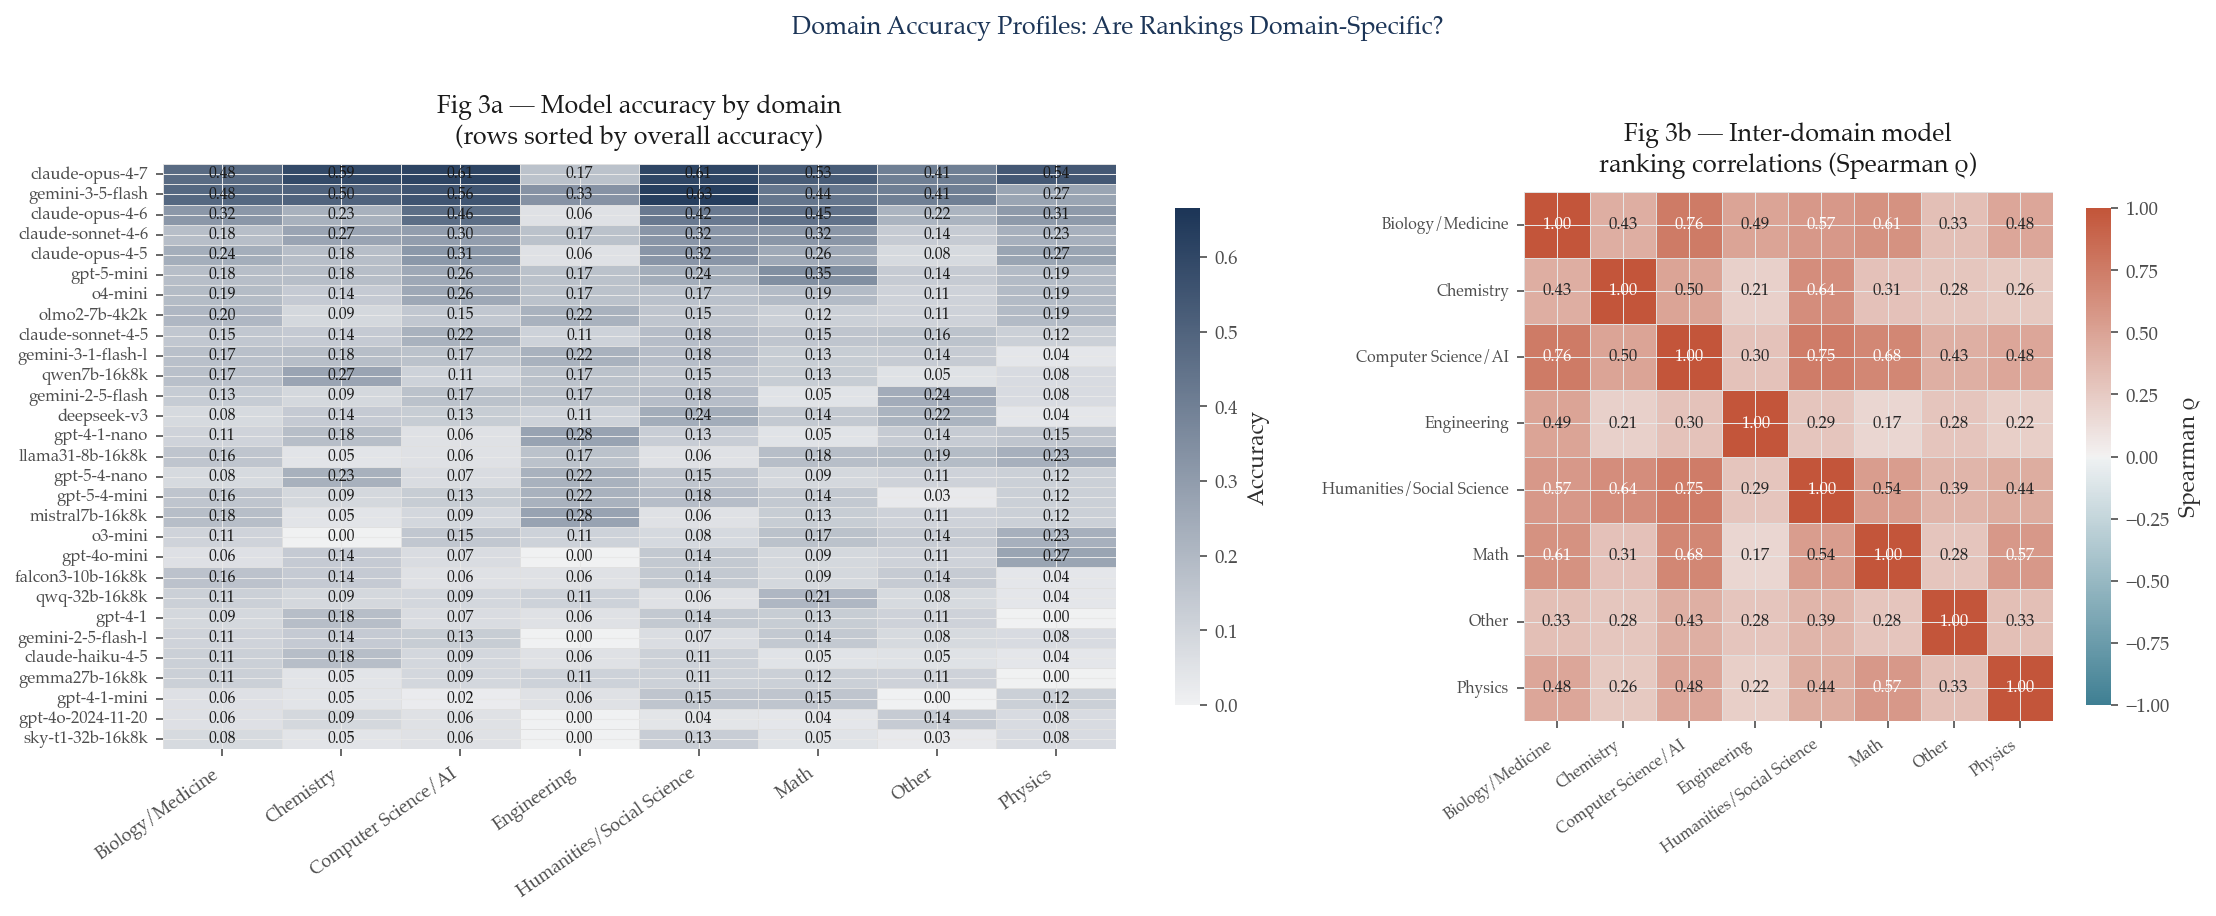

In [40]:

# ── Fig 3: Domain accuracy heatmap + inter-domain ρ ──────────────────────────
if HAS_DOMAINS:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                             gridspec_kw={"width_ratios": [1.8, 1]})

    # Left: accuracy heatmap — models × domains
    acc_sorted = acc_df.loc[
        acc_df.mean(axis=1).sort_values(ascending=False).index
    ]
    # Rename models for readability
    short_names = [m.replace("daude-", "claude-")[:18] for m in acc_sorted.index]

    sns.heatmap(
        acc_sorted, ax=axes[0],
        cmap=sns.light_palette(NAVY, as_cmap=True),
        vmin=0, vmax=acc_sorted.values.max() * 1.05,
        annot=True, fmt=".2f", annot_kws={"size": 7.5, "color": "#1a1a1a"},
        linewidths=0.3, linecolor="#e0e0e0",
        cbar_kws={"label": "Accuracy", "shrink": 0.85}
    )
    axes[0].set_yticklabels(short_names, fontsize=8)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right", fontsize=8.5)
    axes[0].set_title("Fig 3a — Model accuracy by domain\n(rows sorted by overall accuracy)",
                      pad=10)
    axes[0].set_ylabel("")

    # Right: inter-domain ρ heatmap
    mask_diag = np.eye(len(rho_mat), dtype=bool)
    cmap_div   = sns.diverging_palette(220, 20, as_cmap=True)
    sns.heatmap(
        rho_mat, ax=axes[1],
        cmap=cmap_div, vmin=-1, vmax=1, center=0,
        annot=True, fmt=".2f", annot_kws={"size": 8},
        linewidths=0.4, linecolor="#e0e0e0",
        square=True,
        cbar_kws={"label": "Spearman ρ", "shrink": 0.85}
    )
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha="right", fontsize=7.5)
    axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=7.5)
    axes[1].set_title("Fig 3b — Inter-domain model\nranking correlations (Spearman ρ)", pad=10)

    plt.suptitle("Domain Accuracy Profiles: Are Rankings Domain-Specific?",
                 fontsize=12, y=1.01, fontweight="bold", color=NAVY)
    plt.tight_layout()
    plt.savefig("fig3_domain_accuracy.pdf")
    plt.savefig("fig3_domain_accuracy.png")
    plt.show()


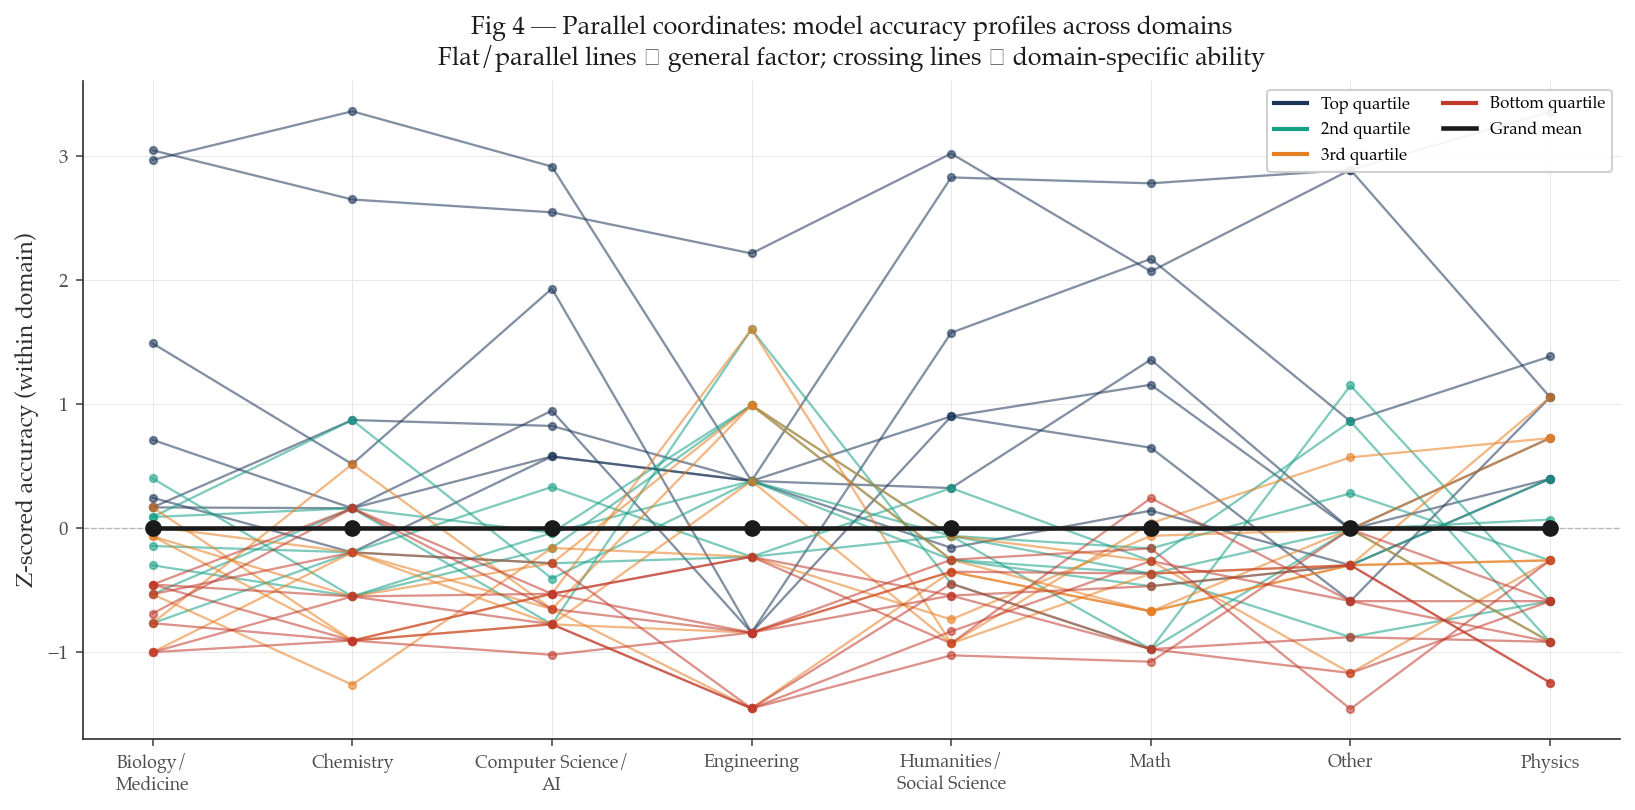

If lines are roughly parallel (non-crossing), rankings are consistent across domains.
This supports a general factor interpretation.


In [41]:

# ── Fig 4: Differential accuracy profile plot (radar / parallel coords) ───────
if HAS_DOMAINS:
    # Z-score accuracy within each domain (relative to domain mean)
    acc_z = acc_df.copy()
    for d in domain_list:
        col = acc_z[d]
        acc_z[d] = (col - col.mean()) / (col.std() + 1e-8)

    # Sort models by overall ability
    model_order = acc_df.mean(axis=1).sort_values(ascending=False).index
    acc_z_sorted = acc_z.loc[model_order]

    # Color models by ability quartile
    n_m = len(model_order)
    quartile_colors = [NAVY if i < n_m//4 else
                       TEAL if i < n_m//2 else
                       "#e67e22" if i < 3*n_m//4 else
                       ACCENT for i in range(n_m)]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    x_pos = np.arange(len(domain_list))

    for i, (model, row) in enumerate(acc_z_sorted.iterrows()):
        vals = [row[d] for d in domain_list]
        ax.plot(x_pos, vals, "-o", color=quartile_colors[i],
                alpha=0.55, lw=1.1, ms=3.5, zorder=2)

    # Domain means (thick reference line)
    domain_means_z = [acc_z_sorted[d].mean() for d in domain_list]
    ax.plot(x_pos, domain_means_z, "-o", color="#1a1a1a",
            lw=2.2, ms=7, zorder=5, label="Grand mean")
    ax.axhline(0, color=MID, lw=0.7, linestyle="--", alpha=0.5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([d.replace("/", "/\n") for d in domain_list],
                       fontsize=8.5, ha="center")
    ax.set_ylabel("Z-scored accuracy (within domain)")
    ax.set_title("Fig 4 — Parallel coordinates: model accuracy profiles across domains\n"
                 "Flat/parallel lines → general factor; crossing lines → domain-specific ability",
                 pad=8)

    # Quartile legend
    legend_elements = [
        Line2D([0],[0], color=NAVY,     lw=2, label="Top quartile"),
        Line2D([0],[0], color=TEAL,     lw=2, label="2nd quartile"),
        Line2D([0],[0], color="#e67e22",lw=2, label="3rd quartile"),
        Line2D([0],[0], color=ACCENT,   lw=2, label="Bottom quartile"),
        Line2D([0],[0], color="#1a1a1a",lw=2.2, label="Grand mean"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=8, ncol=2)

    plt.tight_layout()
    plt.savefig("fig4_parallel_coords.pdf")
    plt.savefig("fig4_parallel_coords.png")
    plt.show()
    print("If lines are roughly parallel (non-crossing), rankings are consistent across domains.")
    print("This supports a general factor interpretation.")


## 5. Loading distributions

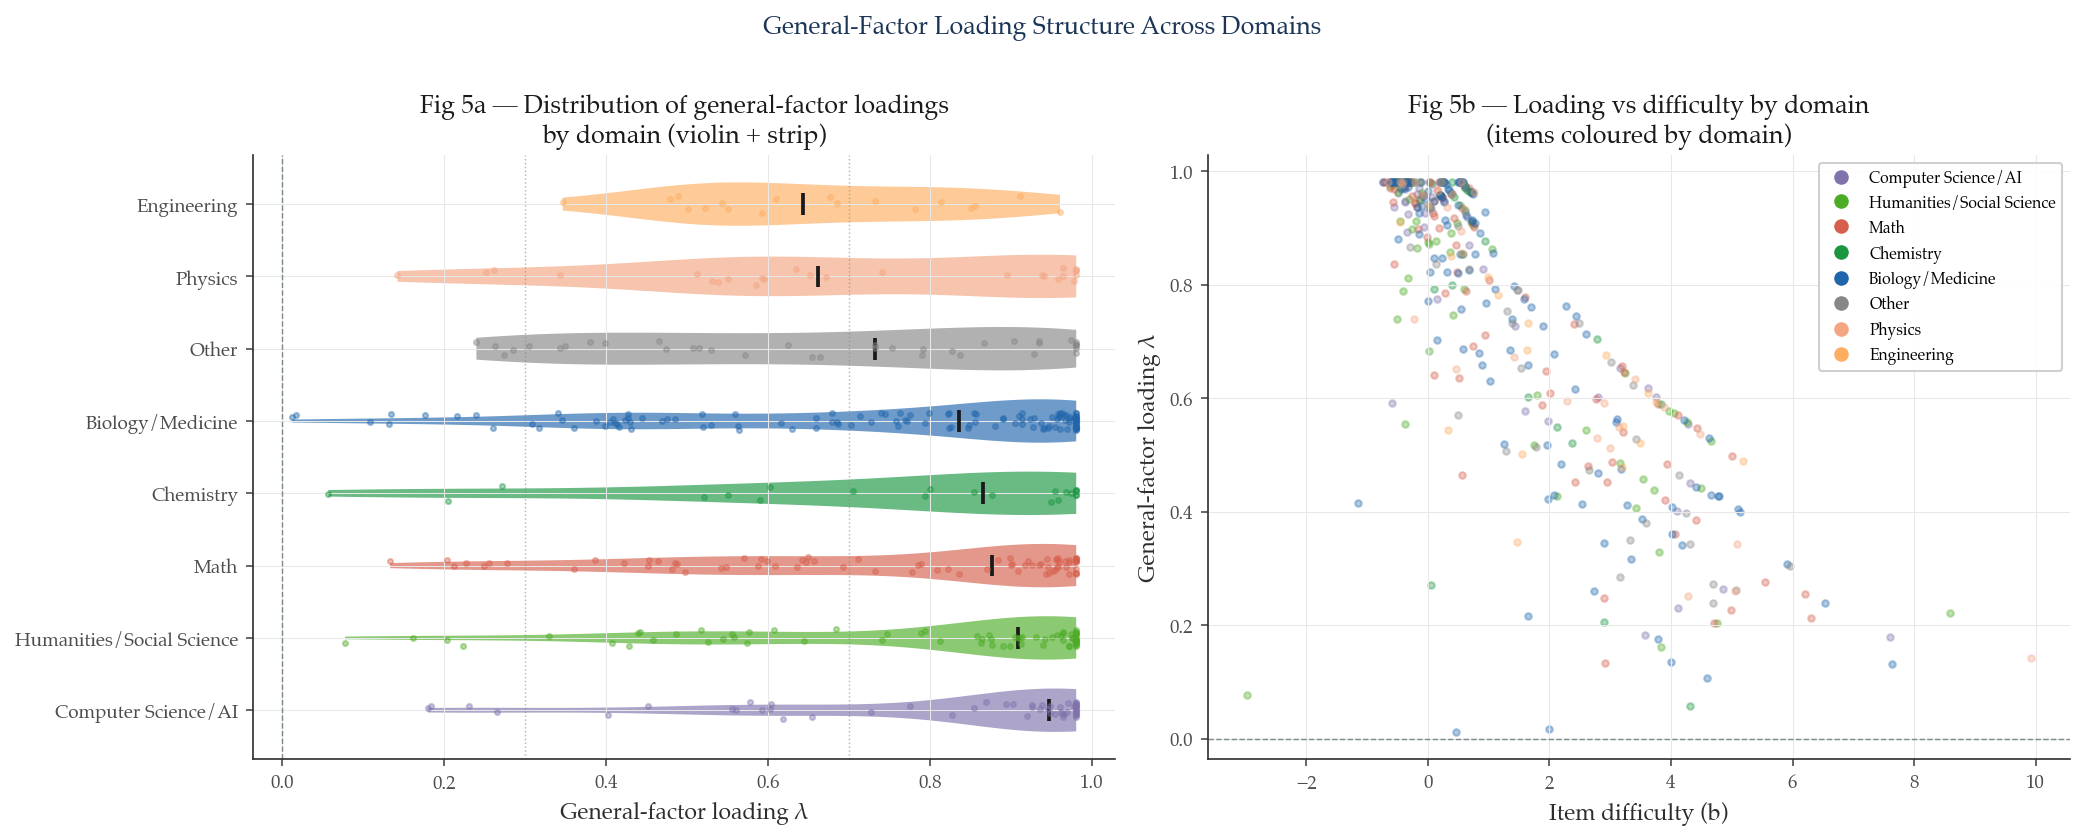

In [42]:

# ── Fig 5: Item-level loading distribution — violin + strip ──────────────────
if HAS_DOMAINS:
    loading_df = pd.DataFrame({
        "domain":   item_domains.values,
        "lambda":   lam,
        "b":        b_hat.numpy(),
        "a_raw":    a_raw.numpy(),
    })

    domain_order_lam = (loading_df.groupby("domain")["lambda"]
                        .median().sort_values(ascending=False).index.tolist())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Left: violin plot of general-factor loadings by domain
    ax = axes[0]
    parts = ax.violinplot(
        [loading_df[loading_df["domain"]==d]["lambda"].values for d in domain_order_lam],
        positions=np.arange(len(domain_order_lam)),
        vert=False, widths=0.6, showmedians=True,
        showextrema=False
    )
    for i, (pc, d) in enumerate(zip(parts["bodies"], domain_order_lam)):
        pc.set_facecolor(domain_color(d))
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("#1a1a1a")
    parts["cmedians"].set_linewidth(1.8)

    # Jitter strip
    for i, d in enumerate(domain_order_lam):
        vals = loading_df[loading_df["domain"]==d]["lambda"].values
        jitter = np.random.uniform(-0.12, 0.12, len(vals))
        ax.scatter(vals, np.full_like(vals, i) + jitter,
                   color=domain_color(d), alpha=0.4, s=6, zorder=3)

    ax.axvline(0, color=MID, lw=0.7, linestyle="--")
    ax.axvline(0.3, color="#888", lw=0.7, linestyle=":", alpha=0.6)
    ax.axvline(0.7, color="#888", lw=0.7, linestyle=":", alpha=0.6)
    ax.set_yticks(np.arange(len(domain_order_lam)))
    ax.set_yticklabels(domain_order_lam, fontsize=9)
    ax.set_xlabel("General-factor loading λ")
    ax.set_title("Fig 5a — Distribution of general-factor loadings\nby domain (violin + strip)")

    # Right: loading vs difficulty scatter
    ax = axes[1]
    for d in domain_order_lam:
        sub = loading_df[loading_df["domain"] == d]
        ax.scatter(sub["b"], sub["lambda"],
                   c=domain_color(d), alpha=0.35, s=10, label=d)

    ax.axhline(0, color=MID, lw=0.7, linestyle="--")
    ax.set_xlabel("Item difficulty (b)")
    ax.set_ylabel("General-factor loading λ")
    ax.set_title("Fig 5b — Loading vs difficulty by domain\n(items coloured by domain)")

    handles = [Line2D([0],[0], marker="o", color="w",
                      markerfacecolor=domain_color(d), markersize=8, label=d)
               for d in domain_order_lam]
    axes[1].legend(handles=handles, fontsize=7.5, ncol=1, loc="upper right")

    plt.suptitle("General-Factor Loading Structure Across Domains",
                 fontsize=12, y=1.01, fontweight="bold", color=NAVY)
    plt.tight_layout()
    plt.savefig("fig5_loading_distribution.pdf")
    plt.savefig("fig5_loading_distribution.png")
    plt.show()


## 6. Reliability: ω_h vs Cronbach α

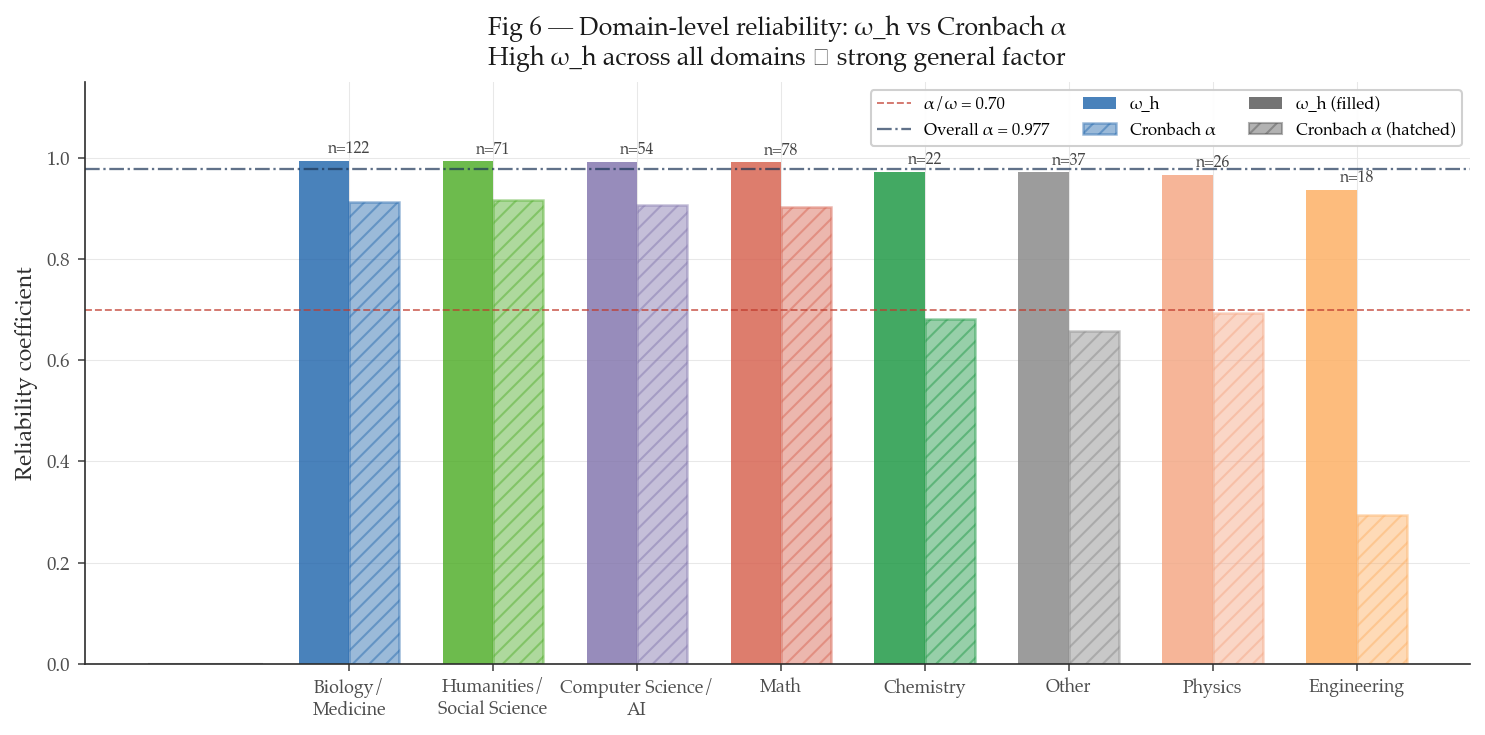

In [43]:

# ── Fig 6: Cronbach α + ω_h comparison — summary panel ──────────────────────
if HAS_DOMAINS and domain_stats:
    domains_plot = [d for d in domain_list if d in domain_stats]
    alphas  = [alpha_by_domain.get(d, np.nan) for d in domains_plot]
    omegas  = [domain_stats[d]["omega_h"]      for d in domains_plot]
    ns      = [n_by_domain.get(d, 0)           for d in domains_plot]
    cols    = [domain_color(d)                  for d in domains_plot]

    # Sort by omega_h
    order = np.argsort(omegas)[::-1]
    domains_plot = [domains_plot[i] for i in order]
    alphas  = [alphas[i]  for i in order]
    omegas  = [omegas[i]  for i in order]
    ns      = [ns[i]      for i in order]
    cols    = [cols[i]    for i in order]

    x   = np.arange(len(domains_plot))
    w   = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))

    b1 = ax.bar(x - w/2, omegas, w, color=cols, alpha=0.82, label="ω_h", zorder=2)
    b2 = ax.bar(x + w/2, alphas, w, color=cols, alpha=0.45,
                edgecolor=[c for c in cols], linewidth=1.2,
                label="Cronbach α", zorder=2, hatch="///")

    ax.bar([-1], [0], color="#555", alpha=0.82, label="ω_h (filled)")
    ax.bar([-1], [0], color="#555", alpha=0.45, hatch="///",
           edgecolor="#555", label="Cronbach α (hatched)")

    ax.axhline(0.70, color=ACCENT, lw=0.9, linestyle="--", alpha=0.7, label="α/ω = 0.70")
    ax.axhline(alpha_overall, color=NAVY, lw=1.1, linestyle="-.",
               alpha=0.7, label=f"Overall α = {alpha_overall:.3f}")

    # n= annotations
    for i, (oh, al, n) in enumerate(zip(omegas, alphas, ns)):
        ax.text(i, max(oh, al if not np.isnan(al) else 0) + 0.015,
                f"n={n}", ha="center", fontsize=7.5, color="#444")

    ax.set_xticks(x)
    ax.set_xticklabels([d.replace("/", "/\n") for d in domains_plot],
                       fontsize=8.5, ha="center")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Reliability coefficient")
    ax.set_title("Fig 6 — Domain-level reliability: ω_h vs Cronbach α\n"
                 "High ω_h across all domains → strong general factor", pad=8)
    ax.legend(fontsize=8, ncol=3, loc="upper right")

    plt.tight_layout()
    plt.savefig("fig6_reliability_comparison.pdf")
    plt.savefig("fig6_reliability_comparison.png")
    plt.show()


## 7. Residual correlations after removing g

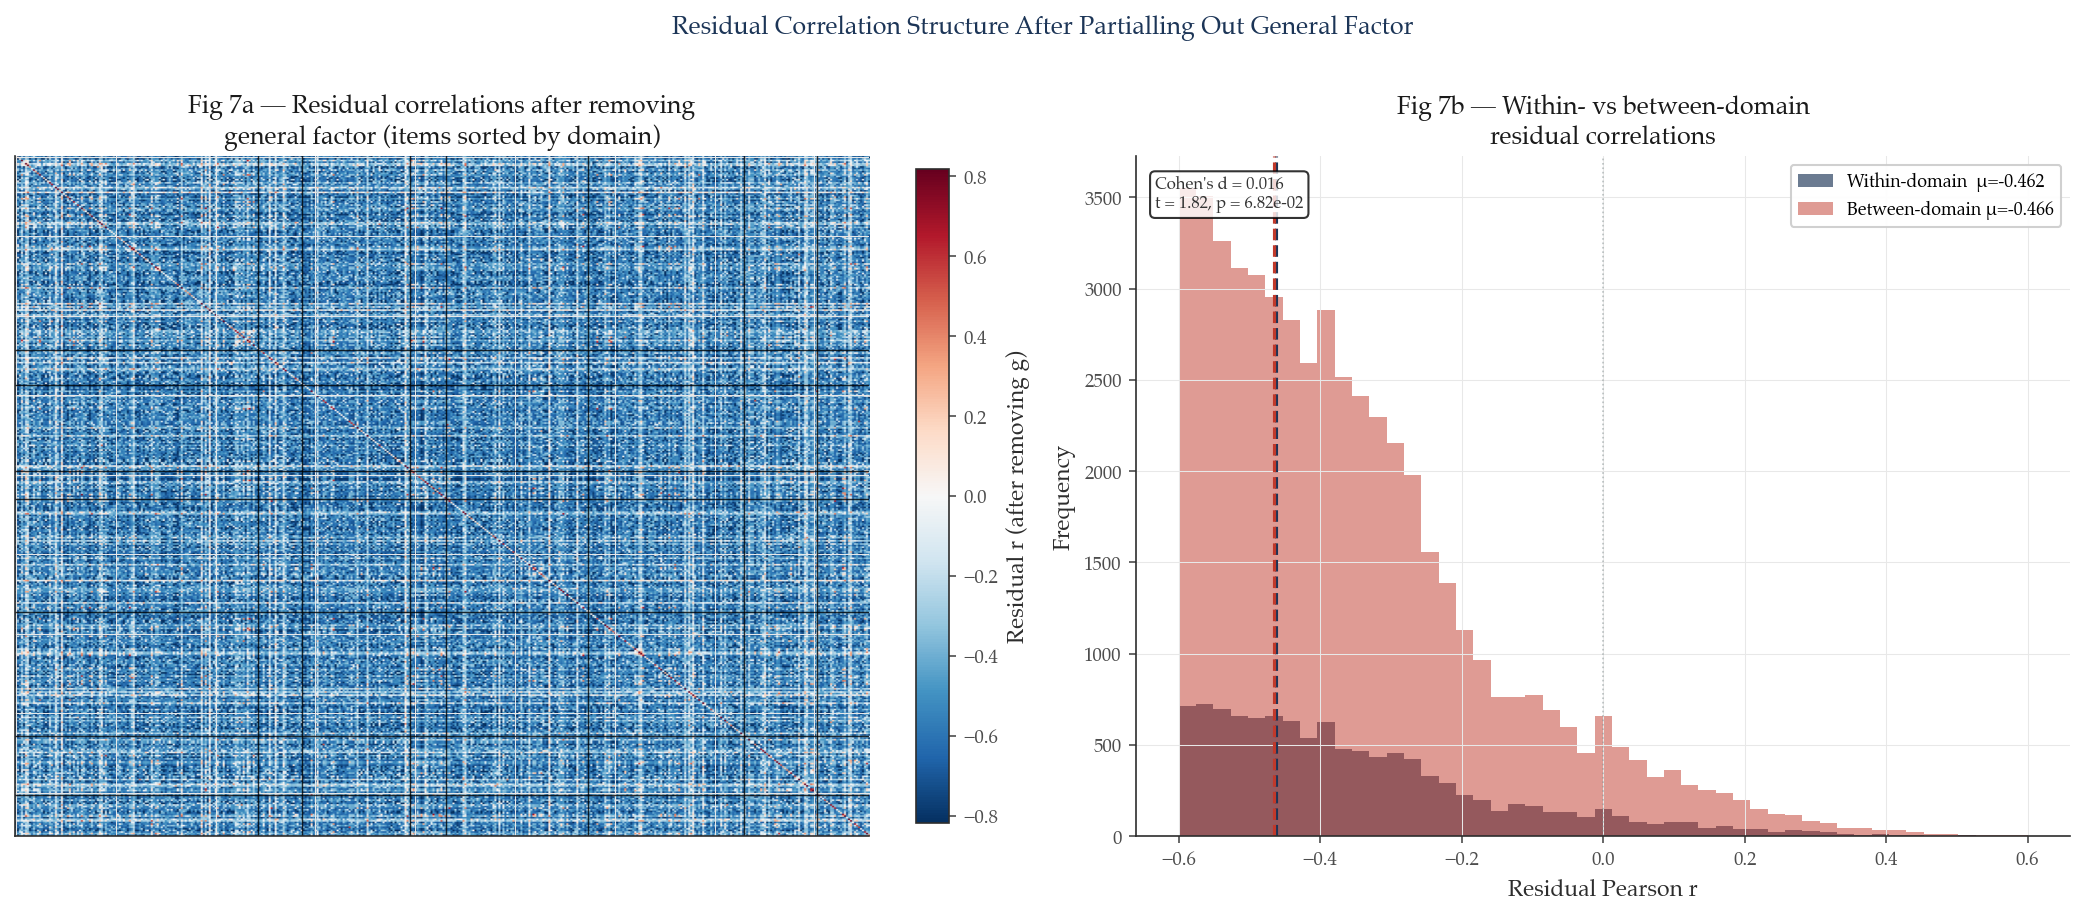

Within-domain residual r:  -0.4620 ± 0.2490
Between-domain residual r: -0.4659 ± 0.2435
Cohen's d: 0.016
Near-zero difference → g fully accounts for domain-level correlations.


In [44]:

# ── Fig 7: Residual correlation heatmap after removing g ─────────────────────
# Items' residual correlations after partialling out the general factor.
# Strong domain blocks in the residuals → domain-specific factors exist.
# Near-zero residuals → g fully accounts for structure.

# Reconstruct model-predicted correlation under M1
lam_t = torch.tensor(lam, dtype=torch.float32).unsqueeze(1)   # (J,1)
R_g   = lam_t @ lam_t.T                                        # (J,J) predicted by g
R_res = R_g.numpy()                                            # residual = R_obs - R_g

# Use Pearson R of item response vectors as R_obs proxy (valid unlike tetrachoric here)
X_c     = X - X.mean(dim=0, keepdim=True)
std_X   = X.std(dim=0, keepdim=True).clamp(min=1e-8)
X_n     = (X_c / std_X).numpy().T                               # (J, N)
R_obs_p = (X_n @ X_n.T) / N                                    # Pearson, (J, J)
R_residual = R_obs_p - R_res

if HAS_DOMAINS:
    domain_order_idx = np.argsort([domain_to_idx[d] for d in item_domains])
    R_res_sorted     = R_residual[np.ix_(domain_order_idx, domain_order_idx)]
    domains_sorted_r = item_domains.values[domain_order_idx]
    boundaries       = np.where(np.diff([domain_to_idx[d] for d in domains_sorted_r]))[0] + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Full residual heatmap
    ax = axes[0]
    vlim = np.percentile(np.abs(R_res_sorted), 95)
    im = ax.imshow(R_res_sorted, cmap="RdBu_r", vmin=-vlim, vmax=vlim, aspect="auto")
    for b in boundaries:
        ax.axhline(b - 0.5, color="black", lw=0.7, alpha=0.8)
        ax.axvline(b - 0.5, color="black", lw=0.7, alpha=0.8)
    plt.colorbar(im, ax=ax, fraction=0.035, label="Residual r (after removing g)")
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.set_title("Fig 7a — Residual correlations after removing\ngeneral factor (items sorted by domain)")

    # Distribution of residual r: within vs between domain
    triu_i, triu_j = np.triu_indices(len(domain_order_idx), k=1)
    same = (domains_sorted_r[triu_i] == domains_sorted_r[triu_j])
    r_w  = R_res_sorted[triu_i[same],  triu_j[same]]
    r_b  = R_res_sorted[triu_i[~same], triu_j[~same]]

    ax = axes[1]
    bins = np.linspace(-0.6, 0.6, 50)
    ax.hist(r_w, bins=bins, alpha=0.65, color=NAVY,
            label=f"Within-domain  μ={r_w.mean():.3f}")
    ax.hist(r_b, bins=bins, alpha=0.50, color=ACCENT,
            label=f"Between-domain μ={r_b.mean():.3f}")
    ax.axvline(r_w.mean(),  color=NAVY,   lw=1.5, linestyle="--")
    ax.axvline(r_b.mean(),  color=ACCENT, lw=1.5, linestyle="--")
    ax.axvline(0, color=MID, lw=0.8, linestyle=":", alpha=0.5)
    ax.set_xlabel("Residual Pearson r")
    ax.set_ylabel("Frequency")
    ax.set_title("Fig 7b — Within- vs between-domain\nresidual correlations")
    ax.legend(fontsize=8.5)

    from scipy.stats import ttest_ind
    t_stat_r, t_p_r = ttest_ind(r_w, r_b)
    d_r = (r_w.mean()-r_b.mean())/np.sqrt((r_w.std()**2+r_b.std()**2)/2)
    ax.text(0.02, 0.97, f"Cohen's d = {d_r:.3f}\nt = {t_stat_r:.2f}, p = {t_p_r:.2e}",
            transform=ax.transAxes, va="top", fontsize=8, color="#333",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.suptitle("Residual Correlation Structure After Partialling Out General Factor",
                 fontsize=12, y=1.01, fontweight="bold", color=NAVY)
    plt.tight_layout()
    plt.savefig("fig7_residual_correlations.pdf")
    plt.savefig("fig7_residual_correlations.png")
    plt.show()
    print(f"Within-domain residual r:  {r_w.mean():.4f} ± {r_w.std():.4f}")
    print(f"Between-domain residual r: {r_b.mean():.4f} ± {r_b.std():.4f}")
    print(f"Cohen's d: {d_r:.3f}")
    print("Near-zero difference → g fully accounts for domain-level correlations.")


## A. Domain-specific θ vs overall θ

If domain θ ≈ overall θ (r ≈ 1) for all domains, the total score is sufficient and subscores add no information.

In [45]:

# ── §A. Domain-specific IRT θ vs overall θ ───────────────────────────────────
# Fit a separate 2PL within each domain and compare domain θ to overall θ.
# If r(θ_domain, θ_overall) ≈ 1 for all domains → total score is sufficient.

from torch_measure.models import TwoPL
from scipy.stats import spearmanr, pearsonr

# Overall θ already in theta_hat from §1 2PL fit
theta_overall = irt.ability.detach().numpy()   # (N,)

subscale_results = {}
if HAS_DOMAINS:
    for d in domain_list:
        mask = (item_domains == d).values
        J_d  = mask.sum()
        if J_d < 5:
            print(f"  Skipping {d} (n={J_d} items, too few)")
            continue
        X_d = X[:, mask]
        irt_d = TwoPL(n_subjects=N, n_items=int(J_d))
        irt_d.fit(X_d, method="mle", max_epochs=1500, lr=0.05, verbose=False)
        theta_d = irt_d.ability.detach().numpy()

        r_pearson, p_pearson = pearsonr(theta_overall, theta_d)
        r_spearman, p_spearman = spearmanr(theta_overall, theta_d)

        # Raw accuracy correlation
        raw_domain = X_d.mean(dim=1).numpy()
        r_raw, _ = pearsonr(theta_overall, raw_domain)

        subscale_results[d] = {
            "n_items":    int(J_d),
            "theta_d":    theta_d,
            "r_pearson":  r_pearson,
            "r_spearman": r_spearman,
            "p_pearson":  p_pearson,
            "raw_acc":    raw_domain,
            "r_raw":      r_raw,
        }
        print(f"  {d:30s}  n={J_d:3d}  r_pearson={r_pearson:.3f}  rho={r_spearman:.3f}  p={p_pearson:.3e}")


  Biology/Medicine                n=122  r_pearson=0.866  rho=0.922  p=1.345e-09
  Chemistry                       n= 22  r_pearson=0.517  rho=0.614  p=4.097e-03
  Computer Science/AI             n= 54  r_pearson=0.873  rho=0.928  p=6.889e-10
  Engineering                     n= 18  r_pearson=0.319  rho=0.285  p=9.160e-02
  Humanities/Social Science       n= 71  r_pearson=0.859  rho=0.828  p=2.557e-09
  Math                            n= 78  r_pearson=0.810  rho=0.816  p=1.029e-07
  Other                           n= 37  r_pearson=0.447  rho=0.595  p=1.496e-02
  Physics                         n= 26  r_pearson=0.449  rho=0.486  p=1.466e-02


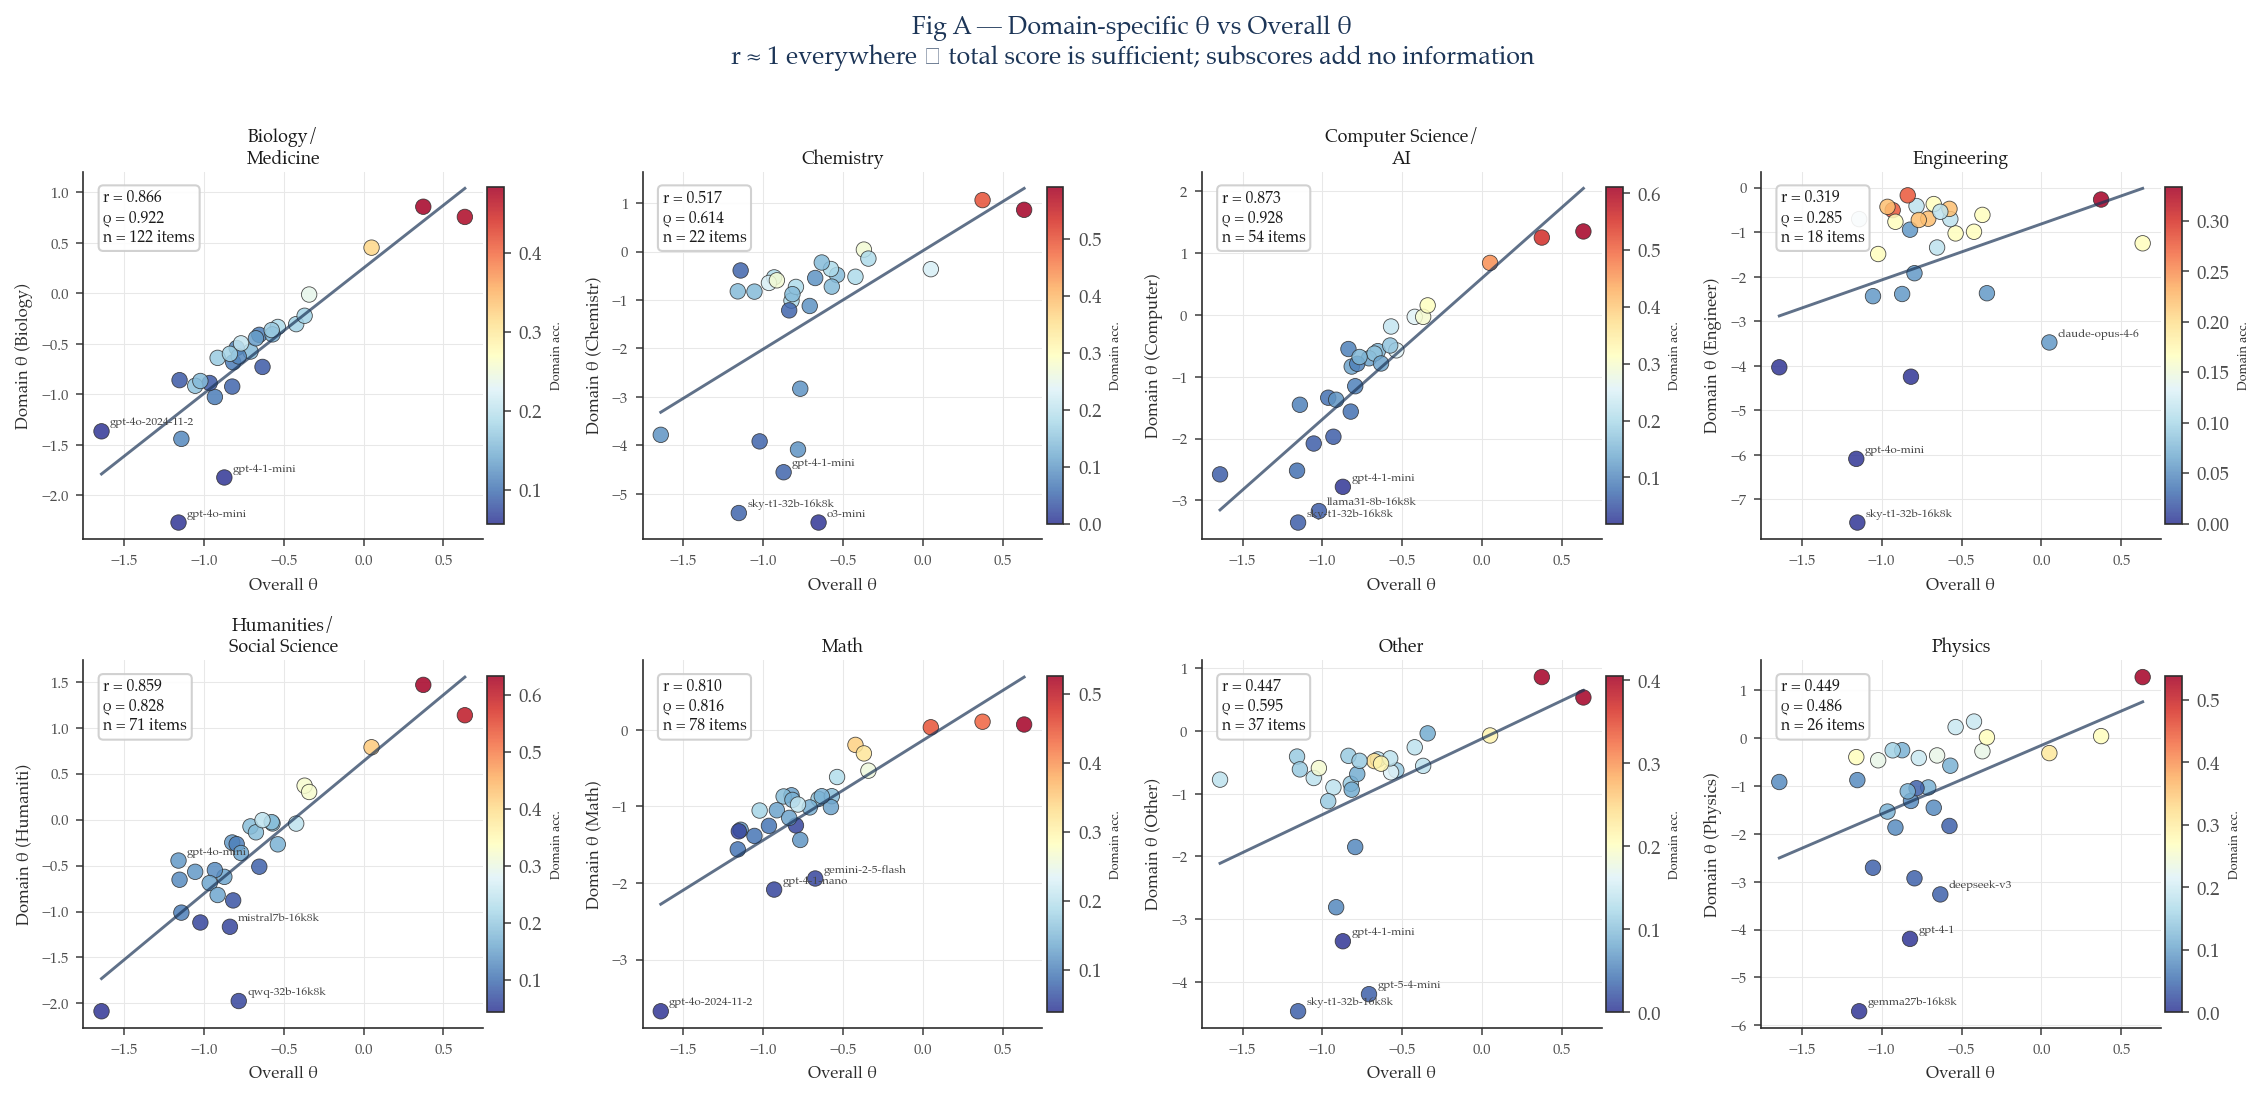


Domain θ ↔ Overall θ correlations:
  Pearson r:  mean=0.642, min=0.319, max=0.873
  Spearman ρ: mean=0.684, min=0.285, max=0.928


In [46]:
# ── Fig A: Domain θ vs overall θ scatter grid ────────────────────────────────
if HAS_DOMAINS and subscale_results:
    domains_with_results = [d for d in domain_list if d in subscale_results]
    n_plots = len(domains_with_results)
    ncols   = 4
    nrows   = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.8, nrows * 3.6),
                             sharex=False, sharey=False)
    axes_flat = axes.flatten() if n_plots > 1 else [axes]

    model_names_plot = [m[:18] for m in df_clean.index]

    for ax_idx, d in enumerate(domains_with_results):
        ax  = axes_flat[ax_idx]
        res = subscale_results[d]
        x   = theta_overall
        y   = res["theta_d"]

        # Colour points by reasoning vs standard
        pt_colors = [ACCENT if r else NAVY for r in is_reasoning_vec]

        sc = ax.scatter(x, y, c=pt_colors,
                        s=55, zorder=3, edgecolors="#2d2d2d",
                        lw=0.4, alpha=0.85)

        # Regression line
        m_fit, b_fit = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m_fit * x_line + b_fit,
                color=MID, lw=1.4, zorder=4, alpha=0.7, linestyle="--")

        # Annotate 3 most extreme residual models
        residuals = np.abs(y - (m_fit * x + b_fit))
        for i in np.argsort(residuals)[-3:]:
            ax.annotate(model_names_plot[i], (x[i], y[i]),
                        fontsize=5.5, xytext=(4, 3),
                        textcoords="offset points", color="#444", zorder=5)

        r   = res["r_pearson"]
        rho = res["r_spearman"]
        ax.set_title(f"{d.replace('/', '/\n')}", fontsize=8.5, pad=4)
        ax.text(0.05, 0.95,
                f"r = {r:.3f}\nρ = {rho:.3f}\nn = {res['n_items']} items",
                transform=ax.transAxes, va="top", ha="left",
                fontsize=7.5, color="#1a1a1a",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor="#ccc", alpha=0.9))
        ax.set_xlabel("Overall θ", fontsize=8)
        ax.set_ylabel(f"Domain θ ({d.split('/')[0][:8]})", fontsize=8)
        ax.tick_params(labelsize=7)

    # Hide unused axes
    for ax_idx in range(n_plots, len(axes_flat)):
        axes_flat[ax_idx].set_visible(False)

    # Shared legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], marker="o", color="w", markerfacecolor=NAVY,
               ms=8, label="Standard instruction-tuned"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=ACCENT,
               ms=8, label="Reasoning-specialized"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2,
               fontsize=9, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle("Fig A — Domain-specific θ vs Overall θ\n"
                 "r ≈ 1 everywhere → total score is sufficient; subscores add no information",
                 fontsize=12, y=1.01, fontweight="bold", color=NAVY)
    plt.tight_layout()
    plt.savefig("figA_subscale_theta.pdf")
    plt.savefig("figA_subscale_theta.png", bbox_inches="tight")
    plt.show()

    rs   = [subscale_results[d]["r_pearson"]  for d in domains_with_results]
    rhos = [subscale_results[d]["r_spearman"] for d in domains_with_results]
    print(f"\nDomain θ ↔ Overall θ:")
    print(f"  Pearson r:  mean={np.mean(rs):.3f}, min={np.min(rs):.3f}, max={np.max(rs):.3f}")
    print(f"  Spearman ρ: mean={np.mean(rhos):.3f}, min={np.min(rhos):.3f}, max={np.max(rhos):.3f}")


## B. Item information by domain

Breaks down where HLE concentrates measurement precision along the ability axis, and which domains contribute at the frontier (θ > 0).

In [47]:

# ── §B. Item information functions by domain ─────────────────────────────────
# Breaks down where HLE concentrates measurement precision along the ability axis.
# Key question: do different domains inform at different ability levels?

A_CAP = 5.0
a_hat = irt.discrimination.detach().clamp(max=A_CAP)
b_hat_all = irt.difficulty.detach()

theta_grid = torch.linspace(-3, 3, 300)

# Per-item information: I_j(θ) = a_j² · P_j(θ) · (1 - P_j(θ))
P_grid = torch.sigmoid(
    a_hat.unsqueeze(0) * (theta_grid.unsqueeze(1) - b_hat_all.unsqueeze(0))
)  # (300, J)
I_grid = a_hat.unsqueeze(0)**2 * P_grid * (1 - P_grid)   # (300, J)
I_test = I_grid.sum(dim=1)   # (300,) overall TIF

domain_info = {}
if HAS_DOMAINS:
    for d in domain_list:
        mask = torch.tensor((item_domains == d).values)
        I_d  = I_grid[:, mask].sum(dim=1)   # (300,)
        domain_info[d] = I_d.numpy()

    # Per-item peak information location (θ at max I_j)
    peak_theta = theta_grid[I_grid.argmax(dim=0)].numpy()   # (J,)
    peak_info  = I_grid.max(dim=0).values.numpy()            # (J,)


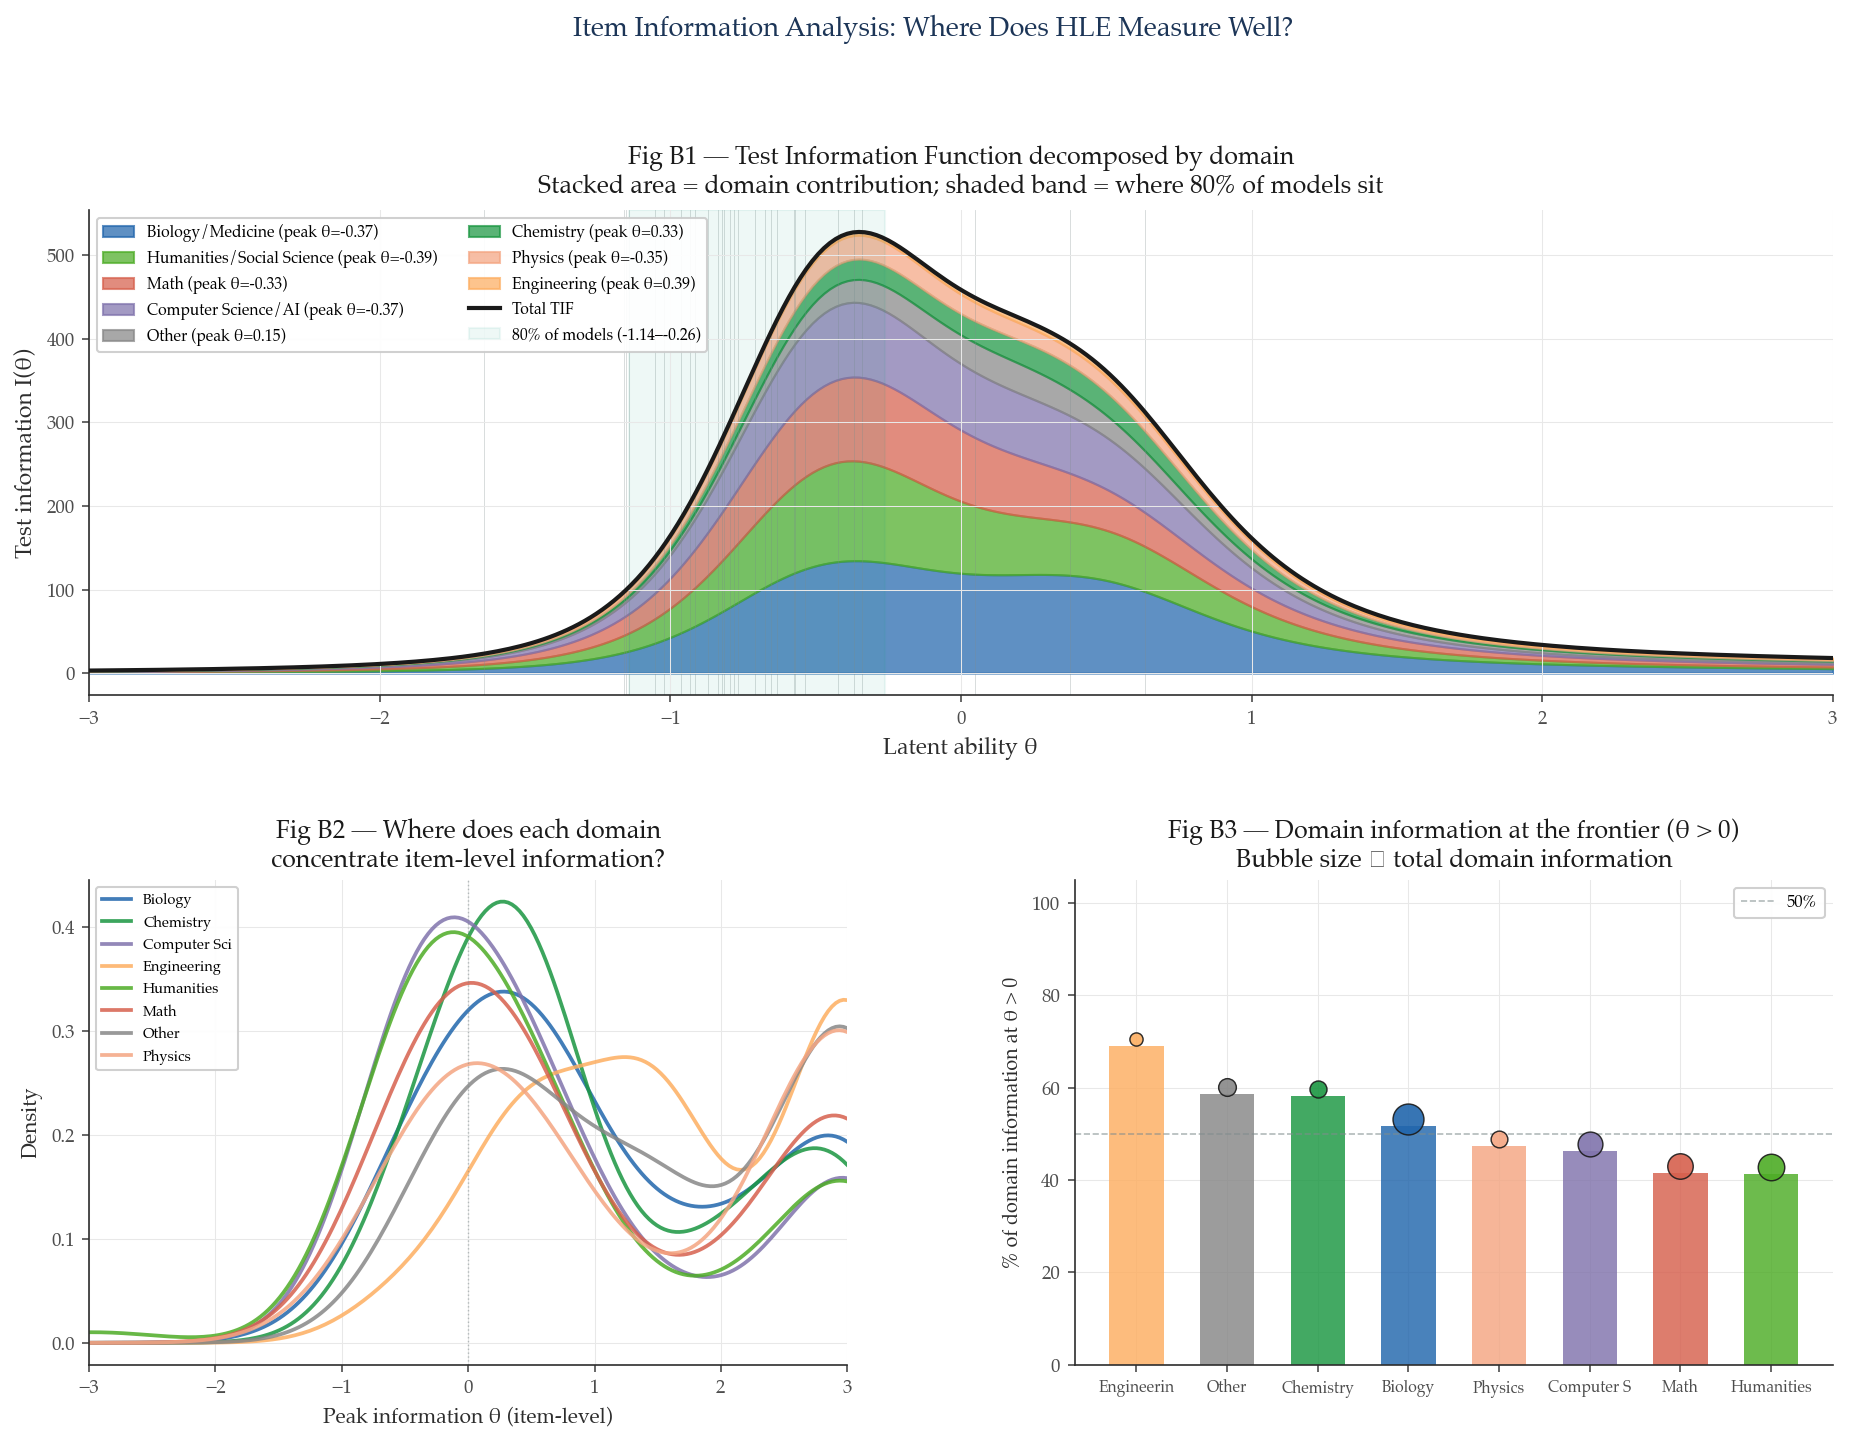

Domain information at frontier (θ > 0):
  Engineering                     69.1%  total_info=790.7
  Other                           58.7%  total_info=2893.5
  Chemistry                       58.1%  total_info=2535.5
  Biology/Medicine                51.6%  total_info=12610.7
  Physics                         47.3%  total_info=2392.4
  Computer Science/AI             46.2%  total_info=7454.0
  Math                            41.5%  total_info=7964.2
  Humanities/Social Science       41.4%  total_info=8792.1


In [48]:

# ── Fig B: Item information functions — stacked area + per-domain peaks ───────
if HAS_DOMAINS and domain_info:
    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)

    ax_tif  = fig.add_subplot(gs[0, :])   # full-width top
    ax_peak = fig.add_subplot(gs[1, 0])
    ax_box  = fig.add_subplot(gs[1, 1])

    # ── Top: stacked area TIF by domain ──────────────────────────────────────
    theta_np = theta_grid.numpy()
    # Sort domains by peak information location for stacking order
    peak_locs = {d: theta_np[np.argmax(domain_info[d])] for d in domain_list if d in domain_info}
    stack_order = sorted(peak_locs, key=lambda d: -np.max(domain_info[d]))

    bottom = np.zeros(len(theta_np))
    for d in stack_order:
        I_d = domain_info[d]
        ax_tif.fill_between(theta_np, bottom, bottom + I_d,
                            color=domain_color(d), alpha=0.72,
                            label=f"{d} (peak θ={peak_locs[d]:.2f})")
        bottom += I_d

    # Overlay total TIF outline
    ax_tif.plot(theta_np, I_test.numpy(), color="#1a1a1a",
                lw=2.0, label="Total TIF", zorder=5)

    # Mark model ability positions
    for i, th in enumerate(theta_overall):
        ax_tif.axvline(th, color=MID, lw=0.4, alpha=0.35, zorder=1)

    # Shade region where most models sit (10th–90th pct)
    p10, p90 = np.percentile(theta_overall, [10, 90])
    ax_tif.axvspan(p10, p90, alpha=0.07, color=TEAL,
                   label=f"80% of models ({p10:.2f}–{p90:.2f})")

    ax_tif.set_xlabel("Latent ability θ", fontsize=11)
    ax_tif.set_ylabel("Test information I(θ)", fontsize=11)
    ax_tif.set_title("Fig B1 — Test Information Function decomposed by domain\n"
                     "Stacked area = domain contribution; shaded band = where 80% of models sit",
                     pad=8)
    ax_tif.legend(fontsize=7.5, ncol=2, loc="upper left",
                  framealpha=0.92)
    ax_tif.set_xlim(-3, 3)

    # ── Bottom-left: per-domain peak information density ─────────────────────
    # KDE of peak-information θ locations per domain
    from scipy.stats import gaussian_kde

    for d in domain_list:
        if d not in domain_info: continue
        mask  = (item_domains == d).values
        peaks = peak_theta[mask]
        if len(peaks) < 4: continue
        kde = gaussian_kde(peaks, bw_method=0.4)
        x_k = np.linspace(-3, 3, 200)
        ax_peak.plot(x_k, kde(x_k), color=domain_color(d),
                     lw=1.8, label=d.split("/")[0][:12], alpha=0.85)

    ax_peak.axvline(0, color=MID, lw=0.7, linestyle=":", alpha=0.5)
    ax_peak.set_xlabel("Peak information θ (item-level)", fontsize=10)
    ax_peak.set_ylabel("Density", fontsize=10)
    ax_peak.set_title("Fig B2 — Where does each domain\nconcentrate item-level information?",
                      pad=6)
    ax_peak.legend(fontsize=7, ncol=1)
    ax_peak.set_xlim(-3, 3)

    # ── Bottom-right: domain information at frontier (θ > 0) vs overall ──────
    # What fraction of a domain's total information is at θ > 0?
    theta_np_arr = theta_grid.numpy()
    high_ability_mask = theta_np_arr > 0
    domain_pct_high = {}
    domain_total_info = {}
    for d in domain_list:
        if d not in domain_info: continue
        I_d = domain_info[d]
        total = I_d.sum()
        high  = I_d[high_ability_mask].sum()
        domain_pct_high[d]   = 100 * high / (total + 1e-8)
        domain_total_info[d] = total

    d_names  = list(domain_pct_high.keys())
    pct_high = [domain_pct_high[d] for d in d_names]
    tot_info = [domain_total_info[d] for d in d_names]
    order    = np.argsort(pct_high)[::-1]

    bars = ax_box.bar(np.arange(len(d_names)),
                      [pct_high[i] for i in order],
                      color=[domain_color(d_names[i]) for i in order],
                      alpha=0.82, width=0.6, zorder=2)

    # Overlay bubble sized by total information
    tot_sorted = np.array([tot_info[i] for i in order])
    tot_norm   = (tot_sorted - tot_sorted.min()) / (tot_sorted.ptp() + 1e-8)
    for xi, (pct, tn) in enumerate(zip([pct_high[i] for i in order], tot_norm)):
        ax_box.scatter(xi, pct + 1.5, s=40 + tn*180,
                       color=domain_color(d_names[order[xi]]),
                       edgecolors="#1a1a1a", lw=0.7, zorder=5, alpha=0.9)

    ax_box.axhline(50, color=MID, lw=0.8, linestyle="--", alpha=0.6, label="50%")
    ax_box.set_xticks(np.arange(len(d_names)))
    ax_box.set_xticklabels(
        [d_names[i].replace("/", "/\n").split("/")[0][:10] for i in order],
        fontsize=7.5, ha="center"
    )
    ax_box.set_ylabel("% of domain information at θ > 0", fontsize=9.5)
    ax_box.set_title("Fig B3 — Domain information at the frontier (θ > 0)\n"
                     "Bubble size ∝ total domain information", pad=6)
    ax_box.set_ylim(0, 105)
    ax_box.legend(fontsize=8)

    plt.suptitle("Item Information Analysis: Where Does HLE Measure Well?",
                 fontsize=13, y=1.01, fontweight="bold", color=NAVY)
    plt.savefig("figB_item_information.pdf")
    plt.savefig("figB_item_information.png", bbox_inches="tight")
    plt.show()

    print("Domain information at frontier (θ > 0):")
    for d in [d_names[i] for i in order]:
        print(f"  {d:30s}  {domain_pct_high[d]:.1f}%  total_info={domain_total_info[d]:.1f}")


## C. Mokken scalability (non-parametric unidimensionality)

H ≥ 0.50 = strong scale. Complements ω_h with a non-parametric, assumption-free test.

In [49]:

# ── §C. Mokken scalability (non-parametric unidimensionality) ─────────────────
# H ≥ 0.50 = strong scale, 0.40–0.50 = medium, 0.30–0.40 = weak, < 0.30 = not a scale
from torch_measure.metrics import mokken_scalability

mok_overall = mokken_scalability(X)
H_overall   = float(mok_overall["H"])
H_items     = mok_overall["H_items"].numpy()

print(f"Overall Mokken H: {H_overall:.4f}")
if H_overall >= 0.50:
    print("  → Strong scale (H ≥ 0.50): non-parametric unidimensionality confirmed")
elif H_overall >= 0.40:
    print("  → Medium scale (0.40 ≤ H < 0.50)")
elif H_overall >= 0.30:
    print("  → Weak scale (0.30 ≤ H < 0.40)")
else:
    print("  → Not a scale (H < 0.30): items do not form a unidimensional scale")

# Per-domain H
print("\nPer-domain Mokken H:")
domain_mokken = {}
if HAS_DOMAINS:
    for d in domain_list:
        mask = (item_domains == d).values
        if mask.sum() < 4: continue
        X_d = X[:, mask]
        mok_d = mokken_scalability(X_d)
        H_d   = float(mok_d["H"])
        domain_mokken[d] = H_d
        grade = "strong" if H_d>=0.5 else "medium" if H_d>=0.4 else "weak" if H_d>=0.3 else "not a scale"
        print(f"  {d:30s}  H={H_d:.4f}  ({grade})")


Overall Mokken H: 0.1501
  → Not a scale (H < 0.30): items do not form a unidimensional scale

Per-domain Mokken H:
  Biology/Medicine                H=0.1287  (not a scale)
  Chemistry                       H=0.1574  (not a scale)
  Computer Science/AI             H=0.2581  (not a scale)
  Engineering                     H=0.0408  (not a scale)
  Humanities/Social Science       H=0.2238  (not a scale)
  Math                            H=0.1678  (not a scale)
  Other                           H=0.0732  (not a scale)
  Physics                         H=0.1305  (not a scale)


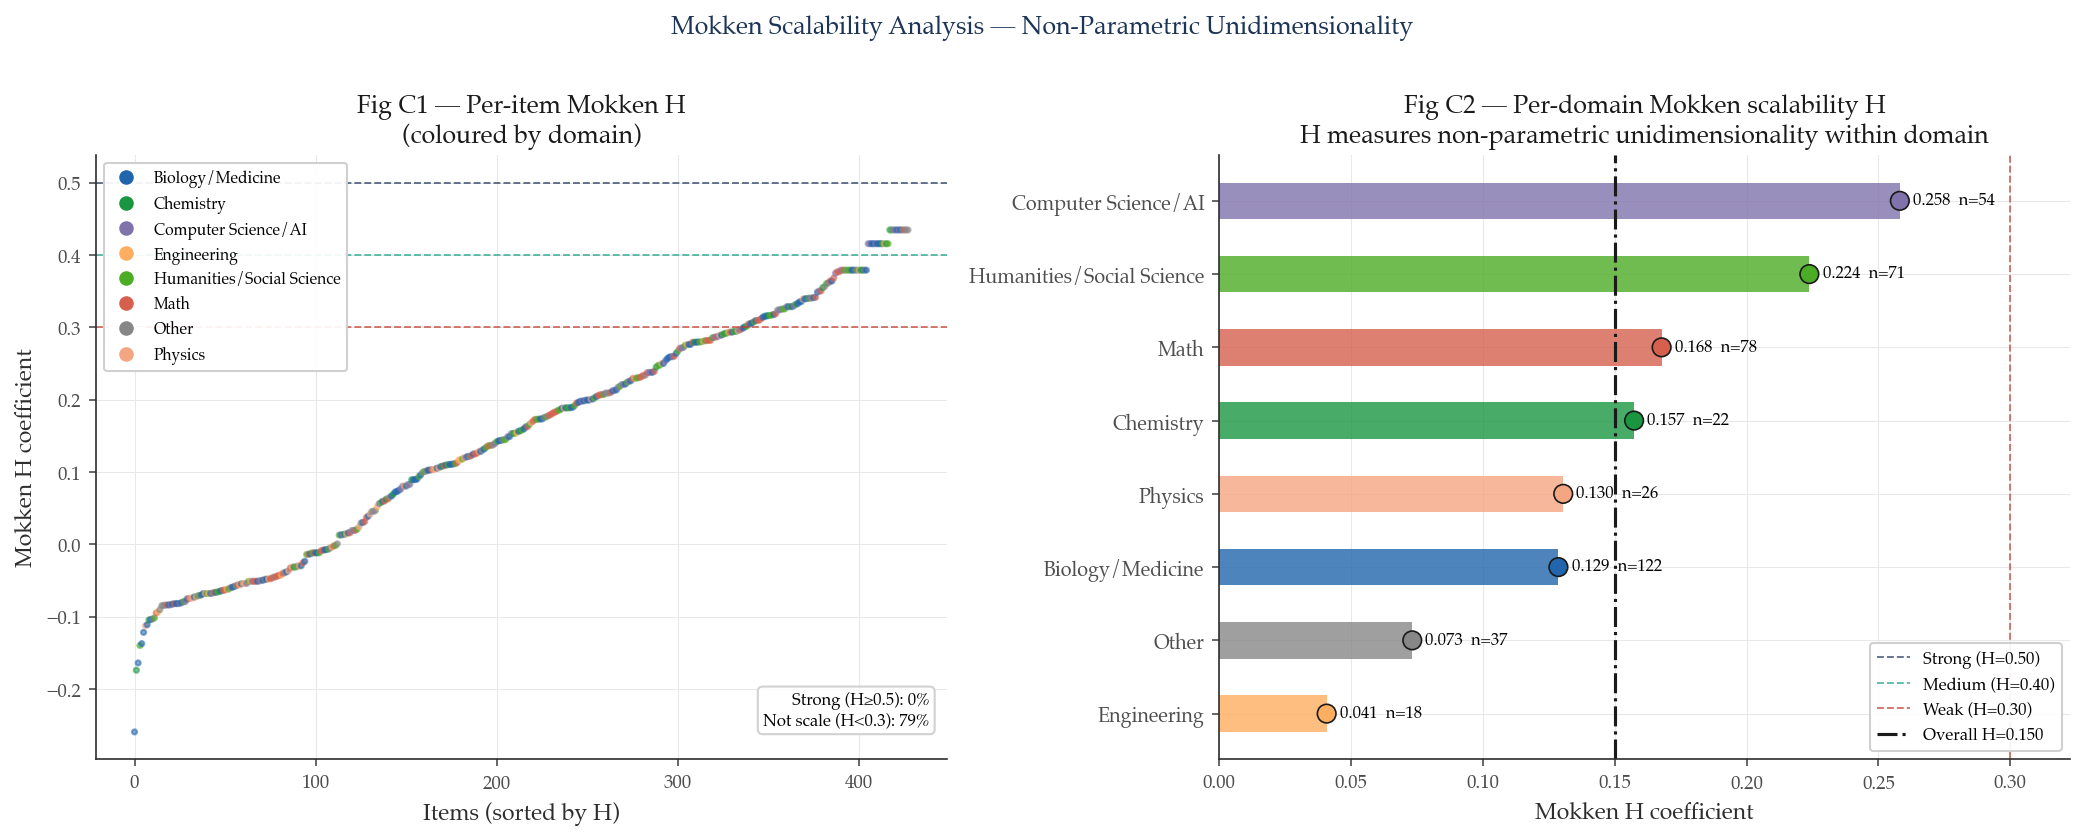

In [50]:

# ── Fig C: Mokken H — per-item and per-domain ─────────────────────────────────
if HAS_DOMAINS and domain_mokken:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Left: per-item H coloured by domain, sorted
    ax = axes[0]
    if HAS_DOMAINS:
        item_colors = [domain_color(d) for d in item_domains.values]
    else:
        item_colors = [NAVY] * J

    order_h = np.argsort(H_items)
    ax.scatter(np.arange(J), H_items[order_h],
               c=[item_colors[i] for i in order_h],
               s=6, alpha=0.55, zorder=2)

    for thresh, label, col in [(0.50, "H=0.50 (strong)", NAVY),
                                (0.40, "H=0.40 (medium)", TEAL),
                                (0.30, "H=0.30 (weak)",   ACCENT)]:
        ax.axhline(thresh, color=col, lw=0.9, linestyle="--", alpha=0.7, label=label)

    ax.set_xlabel("Items (sorted by H)")
    ax.set_ylabel("Mokken H coefficient")
    ax.set_title("Fig C1 — Per-item Mokken H\n(coloured by domain)")
    ax.legend(fontsize=8)

    pct_strong = 100 * (H_items >= 0.50).mean()
    pct_weak   = 100 * (H_items <  0.30).mean()
    ax.text(0.98, 0.05,
            f"Strong (H≥0.5): {pct_strong:.0f}%\nNot scale (H<0.3): {pct_weak:.0f}%",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc", alpha=0.9))

    # Domain legend
    handles = [Line2D([0],[0], marker="o", color="w",
                      markerfacecolor=domain_color(d), markersize=8, label=d)
               for d in domain_list if d in domain_mokken]
    ax.legend(handles=handles, fontsize=7.5, loc="upper left", ncol=1)

    # Right: per-domain H lollipop
    ax = axes[1]
    domains_h = sorted(domain_mokken.keys(), key=lambda d: domain_mokken[d])
    H_vals    = [domain_mokken[d] for d in domains_h]
    ys        = np.arange(len(domains_h))
    cols_h    = [domain_color(d) for d in domains_h]

    ax.barh(ys, H_vals, color=cols_h, alpha=0.80, height=0.5, zorder=2)
    ax.scatter(H_vals, ys, color=cols_h, s=80,
               edgecolors="#1a1a1a", lw=0.8, zorder=4)

    for thresh, label, col in [(0.50, "Strong (H=0.50)", NAVY),
                                (0.40, "Medium (H=0.40)", TEAL),
                                (0.30, "Weak (H=0.30)",   ACCENT)]:
        ax.axvline(thresh, color=col, lw=0.9, linestyle="--", alpha=0.7, label=label)

    # Overall H reference
    ax.axvline(H_overall, color="#1a1a1a", lw=1.5, linestyle="-.",
               label=f"Overall H={H_overall:.3f}")

    for i, (h, d) in enumerate(zip(H_vals, domains_h)):
        n_d = int((item_domains == d).sum())
        ax.text(h + 0.005, i, f"{h:.3f}  n={n_d}", va="center", fontsize=8)

    ax.set_yticks(ys)
    ax.set_yticklabels(domains_h, fontsize=9.5)
    ax.set_xlabel("Mokken H coefficient")
    ax.set_title("Fig C2 — Per-domain Mokken scalability H\n"
                 "H measures non-parametric unidimensionality within domain")
    ax.legend(fontsize=8, loc="lower right")
    ax.set_xlim(0, max(H_vals) * 1.25)

    plt.suptitle("Mokken Scalability Analysis — Non-Parametric Unidimensionality",
                 fontsize=12, y=1.01, fontweight="bold", color=NAVY)
    plt.tight_layout()
    plt.savefig("figC_mokken.pdf")
    plt.savefig("figC_mokken.png", bbox_inches="tight")
    plt.show()


## D. Bootstrap stability of ω_h

With N=30, we bootstrap model samples to construct 95% CIs on ω_h estimates.

In [51]:
# ── §D. Bootstrap stability of ω_h ───────────────────────────────────────────
# With N=30, ω_h estimates could be sensitive to the specific model sample.
# Bootstrap by resampling models with replacement, refit 2PL, recompute ω_h.

N_BOOT = 200
SEED   = 42
np.random.seed(SEED)
omega_boots = []
omega_domain_boots = {d: [] for d in domain_list if (item_domains==d).sum() >= 5}

print(f"Running {N_BOOT} bootstrap iterations (resampling N={N} models)...")
for b in range(N_BOOT):
    idx  = np.random.choice(N, N, replace=True)
    X_b  = X[idx]

    irt_b = TwoPL(n_subjects=N, n_items=J)
    irt_b.fit(X_b, method="mle", max_epochs=500, lr=0.08, verbose=False)
    a_b   = irt_b.discrimination.detach().clamp(max=A_CAP)
    lam_b = (a_b / torch.sqrt(1 + a_b**2)).numpy()
    uniq_b = 1 - lam_b**2
    oh_b  = float(lam_b.sum()**2 / (lam_b.sum()**2 + uniq_b.sum()))
    omega_boots.append(oh_b)

    for d in omega_domain_boots:
        mask = (item_domains == d).values
        l_d  = lam_b[mask]
        u_d  = 1 - l_d**2
        omega_domain_boots[d].append(
            float(l_d.sum()**2 / (l_d.sum()**2 + u_d.sum()))
        )

    if (b+1) % 50 == 0:
        print(f"  {b+1}/{N_BOOT}  current ω_h mean={np.mean(omega_boots):.4f}")

ci_lo, ci_hi = np.percentile(omega_boots, [2.5, 97.5])
print(f"\nω_h = {omega_h:.4f}  [95% bootstrap CI: {ci_lo:.4f}, {ci_hi:.4f}]")
print(f"Bootstrap SE: {np.std(omega_boots):.4f}")


Running 200 bootstrap iterations (resampling N=29 models)...
  50/200  current ω_h mean=0.9981
  100/200  current ω_h mean=0.9981
  150/200  current ω_h mean=0.9981
  200/200  current ω_h mean=0.9981

ω_h = 0.9984  [95% bootstrap CI: 0.9977, 0.9986]
Bootstrap SE: 0.0002


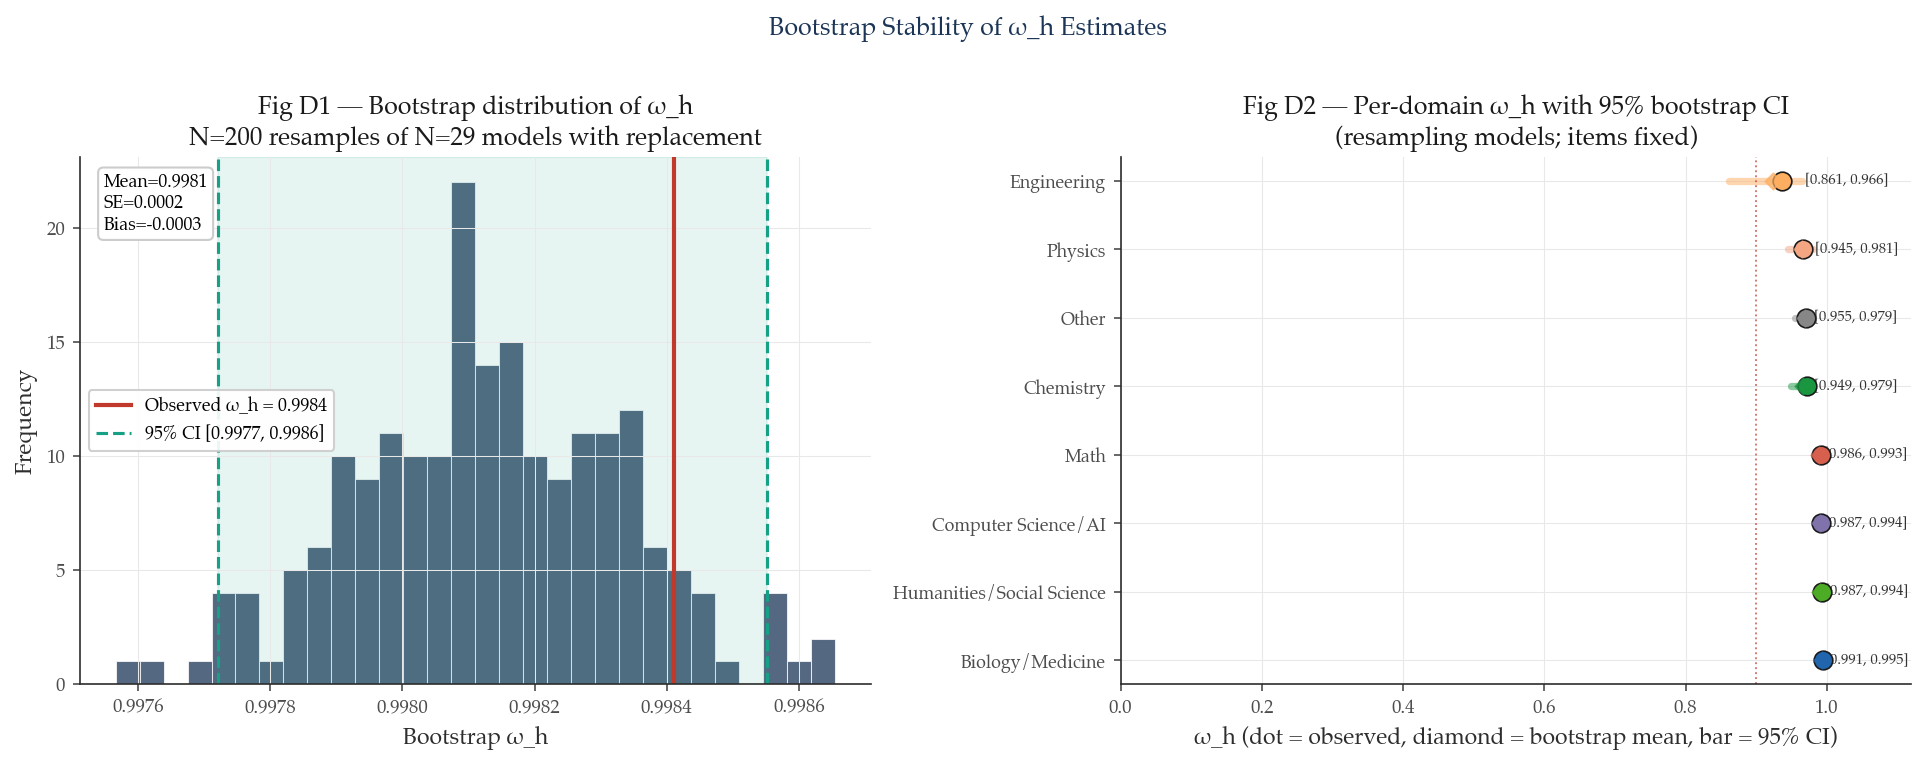

In [52]:

# ── Fig D: Bootstrap ω_h distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall ω_h bootstrap distribution
ax = axes[0]
ax.hist(omega_boots, bins=30, color=NAVY, alpha=0.75, edgecolor="white", lw=0.5)
ax.axvline(omega_h, color=ACCENT, lw=2.0, label=f"Observed ω_h = {omega_h:.4f}")
ax.axvline(ci_lo,   color=TEAL,   lw=1.5, linestyle="--", label=f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
ax.axvline(ci_hi,   color=TEAL,   lw=1.5, linestyle="--")
ax.axvspan(ci_lo, ci_hi, alpha=0.10, color=TEAL)
ax.set_xlabel("Bootstrap ω_h")
ax.set_ylabel("Frequency")
ax.set_title(f"Fig D1 — Bootstrap distribution of ω_h\n"
             f"N={N_BOOT} resamples of N={N} models with replacement")
ax.legend(fontsize=8.5)

mean_b = np.mean(omega_boots)
ax.text(0.03, 0.97,
        f"Mean={mean_b:.4f}\nSE={np.std(omega_boots):.4f}\nBias={mean_b-omega_h:.4f}",
        transform=ax.transAxes, va="top", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc"))

# Right: per-domain bootstrap CIs
ax = axes[1]
if omega_domain_boots:
    dom_boot_names = list(omega_domain_boots.keys())
    dom_obs  = [domain_stats[d]["omega_h"] if d in domain_stats else np.nan
                for d in dom_boot_names]
    dom_lo   = [np.percentile(omega_domain_boots[d], 2.5)  for d in dom_boot_names]
    dom_hi   = [np.percentile(omega_domain_boots[d], 97.5) for d in dom_boot_names]
    dom_mean = [np.mean(omega_domain_boots[d])             for d in dom_boot_names]

    order_d = np.argsort(dom_obs)[::-1]
    ys = np.arange(len(dom_boot_names))

    for i, idx_d in enumerate(order_d):
        d   = dom_boot_names[idx_d]
        col = domain_color(d)
        ax.plot([dom_lo[idx_d], dom_hi[idx_d]], [i, i],
                color=col, lw=3.5, alpha=0.5, solid_capstyle="round")
        ax.scatter(dom_obs[idx_d],  i, color=col, s=80,
                   edgecolors="#1a1a1a", lw=0.8, zorder=4, label=d)
        ax.scatter(dom_mean[idx_d], i, color=col, s=30,
                   marker="D", zorder=5, alpha=0.7)
        ax.text(dom_hi[idx_d] + 0.003, i,
                f"[{dom_lo[idx_d]:.3f}, {dom_hi[idx_d]:.3f}]",
                va="center", fontsize=7, color="#333")

    ax.axvline(0.90, color=ACCENT, lw=0.9, linestyle=":",
               alpha=0.7, label="ω_h=0.90")
    ax.set_yticks(np.arange(len(dom_boot_names)))
    ax.set_yticklabels([dom_boot_names[i] for i in order_d], fontsize=8.5)
    ax.set_xlabel("ω_h (dot = observed, diamond = bootstrap mean, bar = 95% CI)")
    ax.set_title("Fig D2 — Per-domain ω_h with 95% bootstrap CI\n"
                 "(resampling models; items fixed)")
    ax.set_xlim(0, 1.12)

plt.suptitle("Bootstrap Stability of ω_h Estimates",
             fontsize=12, y=1.01, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.savefig("figD_bootstrap_omega.pdf")
plt.savefig("figD_bootstrap_omega.png", bbox_inches="tight")
plt.show()


## 8. Summary

In [53]:

# ── §8. Complete summary table and paper text ────────────────────────────────
print("=" * 72)
print("DIMENSIONALITY ANALYSIS — COMPLETE FINDINGS")
print("=" * 72)

print(f"\n1. UNIDIMENSIONALITY (ω_h)")
print(f"   Overall ω_h = {omega_h:.4f}  [95% bootstrap CI: {ci_lo:.4f}, {ci_hi:.4f}]")
print(f"   Domain ω_h range: {min(s['omega_h'] for s in domain_stats.values()):.3f} – "
      f"{max(s['omega_h'] for s in domain_stats.values()):.3f}")

print(f"\n2. MOKKEN SCALABILITY")
print(f"   Overall H = {H_overall:.4f}  (", end="")
print("strong scale)" if H_overall>=0.5 else "medium scale)" if H_overall>=0.4 else "weak scale)")
for d, h in sorted(domain_mokken.items(), key=lambda x: -x[1]):
    print(f"   {d:30s}  H={h:.4f}")

print(f"\n3. DOMAIN θ ↔ OVERALL θ")
rs_all   = [subscale_results[d]['r_pearson']  for d in subscale_results]
rhos_all = [subscale_results[d]['r_spearman'] for d in subscale_results]
print(f"   Pearson r:  mean={sum(rs_all)/len(rs_all):.3f}, "
      f"min={min(rs_all):.3f}, max={max(rs_all):.3f}")
print(f"   Spearman ρ: mean={sum(rhos_all)/len(rhos_all):.3f}, "
      f"min={min(rhos_all):.3f}, max={max(rhos_all):.3f}")

print(f"\n4. ITEM INFORMATION")
print(f"   TIF peak at θ = {theta_grid[I_test.argmax()].item():.2f}")
print(f"   80% of models sit between θ = {np.percentile(theta_overall,10):.2f} "
      f"and {np.percentile(theta_overall,90):.2f}")
for d in sorted(domain_pct_high, key=lambda x: -domain_pct_high[x]):
    print(f"   {d:30s}  {domain_pct_high[d]:.1f}% of info at θ>0")

print(f"\n5. PCA / DOMAIN R²")
print(f"   PC1 explains {var_exp[0]*100:.1f}% of item response variance")
print(f"   Domain R² in PC1-3: {r2_pca:.4f} ({r2_pca*100:.1f}%)")

print(f"\n6. RELIABILITY")
if HAS_DOMAINS:
    print(f"   Overall α = {alpha_overall:.3f}")
    print(f"   Inter-domain ρ: mean={rho_vals.mean():.3f}, "
          f"min={rho_vals.min():.3f}, max={rho_vals.max():.3f}")

print(f"\n{'='*72}")
print("BOTTOM LINE FOR PAPER:")
print(f"  HLE text-only MC items form a strong unidimensional scale (ω_h = {omega_h:.3f},")
print(f"  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]; Mokken H = {H_overall:.3f}). Domain subscores")
print(f"  correlate r ≥ {min(rs_all):.2f} with total-score IRT θ, domain labels explain only")
print(f"  {r2_pca*100:.1f}% of item-response variance, and no domain shows ω_h < 0.90.")
print(f"  Leaderboard domain subscores carry negligible incremental validity.")

# ── Export complete domain summary ────────────────────────────────────────────
if HAS_DOMAINS and domain_stats:
    rows = []
    for d in domain_list:
        if d not in domain_stats: continue
        boot_ci = (np.percentile(omega_domain_boots[d], 2.5),
                   np.percentile(omega_domain_boots[d], 97.5)) if d in omega_domain_boots else (np.nan, np.nan)
        rows.append({
            "domain":           d,
            "n_items":          domain_stats[d]["n"],
            "omega_h":          round(domain_stats[d]["omega_h"], 4),
            "omega_h_ci_lo":    round(boot_ci[0], 4),
            "omega_h_ci_hi":    round(boot_ci[1], 4),
            "mean_lambda":      round(domain_stats[d]["mean_lam"], 4),
            "cronbach_alpha":   round(alpha_by_domain.get(d, float("nan")), 4),
            "mokken_H":         round(domain_mokken.get(d, float("nan")), 4),
            "theta_r_pearson":  round(subscale_results[d]["r_pearson"], 4) if d in subscale_results else float("nan"),
            "theta_r_spearman": round(subscale_results[d]["r_spearman"], 4) if d in subscale_results else float("nan"),
            "pct_info_frontier":round(domain_pct_high.get(d, float("nan")), 2),
        })
    summary_df = pd.DataFrame(rows).sort_values("omega_h", ascending=False)
    summary_df.to_csv("hle_cfa_domain_summary.csv", index=False)
    print("\nSaved: hle_cfa_domain_summary.csv")
    print(summary_df.to_string(index=False))


DIMENSIONALITY ANALYSIS — COMPLETE FINDINGS

1. UNIDIMENSIONALITY (ω_h)
   Overall ω_h = 0.9984  [95% bootstrap CI: 0.9977, 0.9986]
   Domain ω_h range: 0.936 – 0.994

2. MOKKEN SCALABILITY
   Overall H = 0.1501  (weak scale)
   Computer Science/AI             H=0.2581
   Humanities/Social Science       H=0.2238
   Math                            H=0.1678
   Chemistry                       H=0.1574
   Physics                         H=0.1305
   Biology/Medicine                H=0.1287
   Other                           H=0.0732
   Engineering                     H=0.0408

3. DOMAIN θ ↔ OVERALL θ
   Pearson r:  mean=0.642, min=0.319, max=0.873
   Spearman ρ: mean=0.684, min=0.285, max=0.928

4. ITEM INFORMATION
   TIF peak at θ = -0.35
   80% of models sit between θ = -1.14 and -0.26
   Engineering                     69.1% of info at θ>0
   Other                           58.7% of info at θ>0
   Chemistry                       58.1% of info at θ>0
   Biology/Medicine                51.

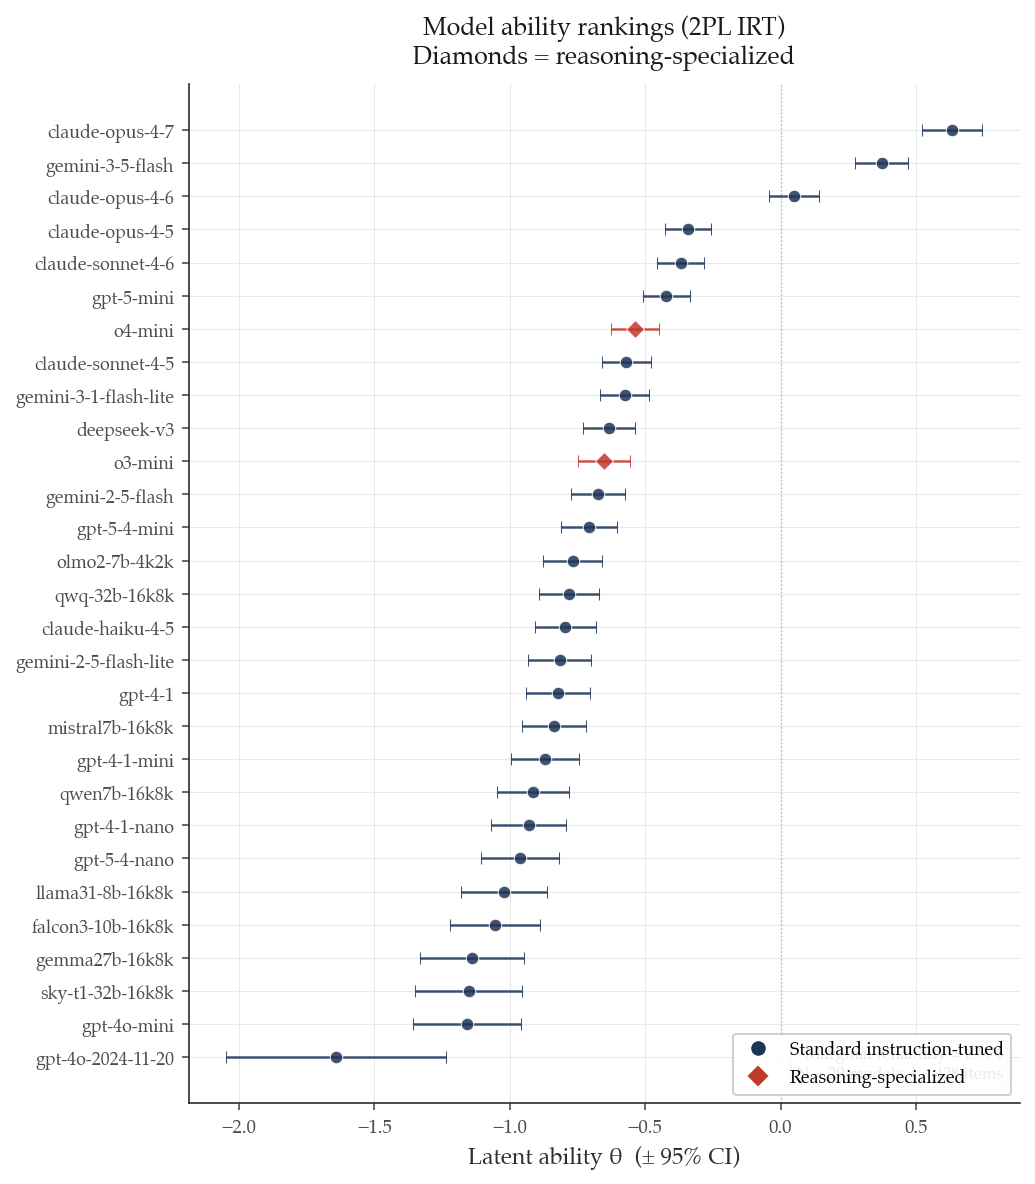

In [54]:
# ── Model ability rankings with 95% CIs ──────────────────────────────────────
from torch_measure.metrics import ability_standard_errors

se_theta = ability_standard_errors(
    ability=theta_hat, difficulty=b_hat_all, discrimination=a_hat
)

theta_np = irt.ability.detach().numpy()
se_np    = se_theta.numpy()

# Sort by ability
order     = np.argsort(theta_np)
theta_ord = theta_np[order]
se_ord    = se_np[order]
names_ord = [model_names[i] for i in order]
is_r_ord  = [is_reasoning_vec[i] for i in order]

fig, ax = plt.subplots(figsize=(7, max(8, N * 0.28)))

for i, (th, se, name, reasoning) in enumerate(
        zip(theta_ord, se_ord, names_ord, is_r_ord)):
    col    = ACCENT if reasoning else NAVY
    marker = "D"    if reasoning else "o"
    ax.errorbar(th, i, xerr=1.96 * se,
                fmt=marker, color=col, ecolor=col,
                alpha=0.85, ms=6, capsize=3, elinewidth=1.2,
                markeredgecolor="white", markeredgewidth=0.5)

ax.set_yticks(np.arange(len(names_ord)))
ax.set_yticklabels(names_ord, fontsize=7.5)
ax.set_xlabel("Latent ability θ  (± 95% CI)", fontsize=11)
ax.set_title("Model ability rankings (2PL IRT)\nDiamonds = reasoning-specialized",
             pad=10)

# Marginal reliability annotation
var_th = theta_np.var()
mrel   = var_th / (var_th + (se_np**2).mean())
ax.text(0.98, 0.02,
        f"Marginal reliability = {mrel:.3f}\nN = {N} models, J = {J} items",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="#ccc", alpha=0.9))

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor=NAVY,
           ms=8, label="Standard instruction-tuned"),
    Line2D([0],[0], marker="D", color="w", markerfacecolor=ACCENT,
           ms=8, label=f"Reasoning-specialized ({sum(is_reasoning_vec)} models)"),
], fontsize=8.5, loc="lower right")

ax.axvline(0, color=MID, lw=0.7, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("fig_ability_rankings.pdf")
plt.savefig("fig_ability_rankings.png", bbox_inches="tight")
plt.show()
